# Initalization

In [2]:
%matplotlib inline

In [5]:
import os

import numpy as np
import warnings
warnings.filterwarnings('ignore', message='No contour levels were found')

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.path as mpath

mpl.rcParams['font.size'] = 10
mpl.rcParams['figure.dpi'] = 150
# # mpl.rcParams['pdf.use14corefonts'] = True
# # mpl.rcParams['pdf.fonttype'] = 42
# # mpl.rcParams['font.sans-serif'] = 'DejaVu Sans'
mpl.rcParams['hatch.linewidth'] = 0.5
mpl.rcParams['hatch.color'] = '0.25'

colors = ['#1f77b4',
 '#ff7f0e',
 '#2ca02c',
 '#d62728',
 '#9467bd',
 '#8c564b',
 '#e377c2',
 '#7f7f7f',
 '#bcbd22',
 '#17becf']

import cmocean

import cartopy.crs as ccrs
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

import xarray as xr

import ipywidgets as widgets
import xgcm

from numpy import pi as π

import sys
sys.path.append('../analysis/')
# m6toolbox is a python package that has a function that helps visualize vertical sections
import m6toolbox

sys.path.insert(0, '../pittwolfe')
import pittwolfe as pw
from pittwolfe.util import sind, cosd

latFormatter = pw.plt.LatitudeFormatter(direction_labels=False)
lonFormatter = pw.plt.LongitudeFormatter(direction_labels=False)

## Specify the experiment

In [759]:
####
# flat bottom base 0.5º experiment
# expdir = '../../flat/base'
# recirc_lon = [0, 8]
# recirc_lat = [32, 39]
# recirc_lon0 = 1.25

####
# flat bottom 0.25º experiment
# expdir = '../../flat/0.25'
# recirc_lon = [0, 8]
# recirc_lat = [32, 39]
# recirc_lon0 = 1.25

####
# flat bottom 0.5º experiment with GM & K = 500
# expdir = '../../flat/gm_0500'
# recirc_lon = [0, 8]
# recirc_lat = [32, 39]
# recirc_lon0 = 1.25

####
# sloping sidewalls, 0.5º 
expdir = '../../slope/base'
recirc_lon0 = 1.25
recirc_lon = [0, 8]
recirc_lat = [32, 39]

####
# sloping sidewalls, 0.25º 
# expdir = '../../slope/0.25'
# recirc_lon0 = 4.5
# recirc_lon = [0, 10]
# recirc_lat = [31, 38]


# Function definitions

In [760]:
def savefig(fig, name, pdf=True, png=True):
    if pdf:
        fig.savefig(os.path.join(expdir, name + '.pdf'), bbox_inches='tight')
    if png:
        fig.savefig(os.path.join(expdir, name + '.png'), bbox_inches='tight', dpi=150)

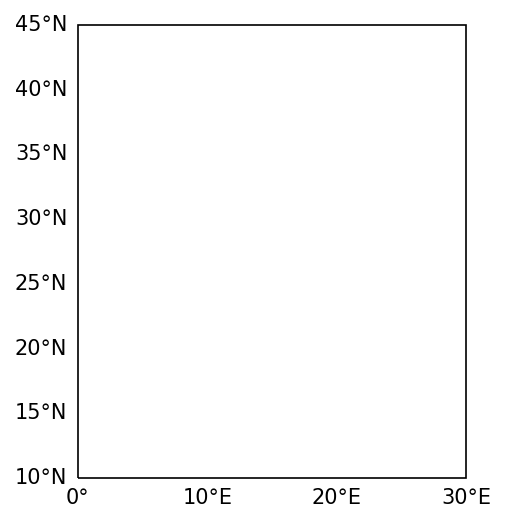

In [761]:
def setup_cartopy_plot(ax=None, bottom_labels=True, left_labels=True):
    data_projection = ccrs.PlateCarree()
    map_projection = ccrs.PlateCarree()
#     map_projection = ccrs.AlbersEqualArea(central_longitude=15, 
#                                           central_latitude=25,
#                                           standard_parallels=(20.0, 50.0))

    if ax is None:
        ax = plt.axes(projection=map_projection)

    ax.set_extent([-0.001, 30.001, 9.999, 45.0001], crs=ccrs.PlateCarree())
    gl = ax.gridlines(xlocs=np.arange(0, 31, 10), draw_labels=True)
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = bottom_labels
    gl.left_labels = left_labels
    gl.xlines = False
    gl.ylines = False

    vertices = [
        [ 0, 10],
        [30, 10],
        [30, 45],
        [ 0, 45],
        [ 0, 10]
    ]

    path = mpath.Path(vertices).interpolated(20)

#     ax.background_patch.set_facecolor('.5')
#     xlocs = np.arange(-90, 240, 30)
#     ylocs = np.arange(-75, 90, 15)
#     ax.gridlines(xlocs=xlocs, ylocs=ylocs, linewidth=.5)
#     ax.set_boundary(path, transform=data_projection)
    
    return ax

fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
setup_cartopy_plot(ax)
savefig(fig, 'test')

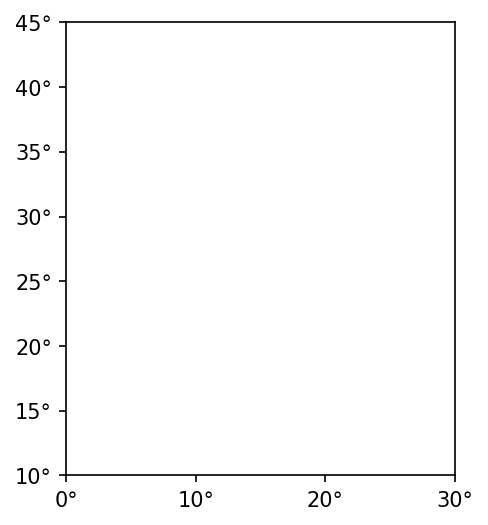

In [762]:
def setup_plan_plot(ax=None):
    if ax is None:
        ax = plt.axes()

    ax.set_xlim(0, 30)
    ax.set_ylim(10, 45)
    
    yticks = np.arange(10, 46, 5)
    latFormatter = pw.plt.LatitudeFormatter(direction_labels=False)
    ax.set_yticks(yticks)
    ax.set_yticklabels(latFormatter.format(yticks))
    
    xticks = np.arange(0, 31, 10)
    lonFormatter = pw.plt.LongitudeFormatter(direction_labels=False)
    ax.set_xticks(xticks)
    ax.set_xticklabels(lonFormatter.format(xticks))
    
    ax.set_aspect(1)
    
    return ax

fig, ax = plt.subplots()
setup_plan_plot(ax)
savefig(fig, 'test')

In [763]:
def integer_ticks(vmax, symmetric=True, spacing=None, nticks=None):
    '''
    Returns an array with ticks spaced by an integer and centered around zero.
    
    nticks is the number of non-negative ticks
    '''
    
    if spacing is not None and nticks is not None:
        raise RuntimeError("Can't specify both spacing and nticks")
        
    if spacing is not None:
        if symmetric:
            vmin = -np.floor(vmax/spacing)*spacing
        else:
            vmin = 0
            
        return np.arange(vmin, vmax*(1 + .01), spacing)
    
    if nticks is None:
        nticks = 4
        
    spacing = np.ceil(vmax/nticks)
    if symmetric:
        vmin = -np.floor(vmax/spacing)*spacing
    else:
        vmin = 0
    return np.arange(vmin, vmax*(1 + .01), spacing)
    

# Load datasets

## Constants

In [764]:
ρ0 = 1035 # Boussinesq reference density
g = 9.8
Ω = 7.29e-5
a = 6370e3
Ah = 1e4
Δλ = 0.5 # zonal grid spacing

max_depth = float(grid.D.max())

NTavg = 10 # number of years to average
tavg = slice(-10, None)

## Grid

MOM calls coordinates different things in different outputs. This enforces as uniform standard.

In [765]:
coord_map_h = {'lath': 'yh', 'latq': 'yq', 'lonh': 'xh', 'lonq': 'xq'}
coord_map_v = {'Interface': 'zi', 'Layer': 'zl'}

Vertical coordinates are annoyingly not in `ocean_geometry.nc`. We load them from the initial conditions and add them to the grid.

In [766]:
grid = xr.open_dataset(os.path.join(expdir, 'OUTPUT/ocean_geometry.nc')).rename(coord_map_h)
ic = xr.open_dataset(os.path.join(expdir, 'OUTPUT/MOM_IC.nc')).squeeze().rename({**coord_map_h, **coord_map_v})

Nx = len(grid.xh)
Ny = len(grid.yh)

grid['zi'] = ic.zi
grid['zl'] = ic.zl

grid['fh'] = 2*Ω*sind(grid.yh)
grid['fq'] = 2*Ω*sind(grid.yq)

grid['βh'] = 2*Ω*cosd(grid.yh)/a
grid['βq'] = 2*Ω*cosd(grid.yq)/a

grid['maskH'] = grid.wet
grid['maskU'] = (['yh', 'xq'], np.ones((Ny, Nx+1)))
grid['maskU'][:,[0, -1]] = 0
grid['maskV'] = (['yq', 'xh'], np.ones((Ny+1, Nx)))
grid['maskV'][[0, -1],:] = 0

grid['maskZ'] = (['yq', 'xq'], np.ones((Ny+1, Nx+1)))
grid['maskZ'][[0, -1],:] = 0
grid['maskZ'][:,[0, -1]] = 0

# width of the basin in meters
grid['Lx_q'] = a*np.deg2rad(grid.geolonb.isel(xq=-1,yq=0))*cosd(grid.yq)
grid['Lx_h'] = a*np.deg2rad(grid.geolonb.isel(xq=-1,yq=0))*cosd(grid.yh)

grid

<xarray.Dataset>
Dimensions:  (yh: 81, xh: 60, yq: 82, xq: 61, zi: 3, zl: 2)
Coordinates:
  * yh       (yh) float64 10.25 10.74 11.23 11.72 ... 43.79 44.15 44.5 44.86
  * xh       (xh) float64 0.25 0.75 1.25 1.75 2.25 ... 28.25 28.75 29.25 29.75
  * yq       (yq) float64 10.0 10.49 10.98 11.47 ... 43.97 44.33 44.68 45.04
  * xq       (xq) float64 0.0 0.5 1.0 1.5 2.0 2.5 ... 28.0 28.5 29.0 29.5 30.0
    Time     timedelta64[ns] 00:00:00
  * zi       (zi) float64 1.034e+03 1.036e+03 1.037e+03
  * zl       (zl) float64 1.035e+03 1.036e+03
Data variables: (12/29)
    geolatb  (yq, xq) float64 ...
    geolonb  (yq, xq) float64 ...
    geolat   (yh, xh) float64 ...
    geolon   (yh, xh) float64 ...
    D        (yh, xh) float64 ...
    f        (yq, xq) float64 ...
    ...       ...
    maskH    (yh, xh) float64 ...
    maskU    (yh, xq) float64 0.0 1.0 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0 1.0 0.0
    maskV    (yq, xh) float64 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    maskZ    (yq, xq) float64 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    Lx_q     (yq) float64 3.285e+06 3.28e+06 3.274e+06 ... 2.371e+06 2.357e+06
    Lx_h     (yh) float64 3.282e+06 3.277e+06 3.271e+06 ... 2.379e+06 2.364e+06
Attributes:
    filename:  ./ocean_geometry.nc

In [767]:
grid_op = xgcm.Grid(grid, periodic=False, boundary='fill', fill_value=0, coords={
    'X': {'center': 'xh', 'outer': 'xq'},
    'Y': {'center': 'yh', 'outer': 'yq'},
    'Z': {'inner': 'zl', 'outer': 'zi'},

})
grid_op

<xgcm.Grid>
X Axis (not periodic, boundary='fill'):
  * center   xh --> outer
  * outer    xq --> center
Y Axis (not periodic, boundary='fill'):
  * center   yh --> outer
  * outer    yq --> center
Z Axis (not periodic, boundary='fill'):
  * inner    zl
  * outer    zi

## Forcing

In [768]:
forcing = xr.open_dataset(os.path.join(expdir, 'INPUT/forcing.nc'))

# make sure the coordinates match exactly
forcing['xh'] = grid.xh 
forcing['xq'] = grid.xq[:-1]
forcing['yh'] = grid.yh
forcing['yq'] = grid.yq[:-1]

forcing['uEk'] =  forcing.STRESS_Y/grid.fq/ρ0
forcing['vEk'] = -forcing.STRESS_X/grid.fh/ρ0
forcing['wEk'] = grid.maskZ*(grid_op.diff(forcing.uEk*grid.dyCv, 'X') + grid_op.diff(forcing.vEk*grid.dxCu, 'Y'))/grid.Aq
forcing['wsc'] = grid.maskZ*(grid_op.diff(forcing.STRESS_Y*grid.dyCv, 'X') - grid_op.diff(forcing.STRESS_X*grid.dxCu, 'Y'))/grid.Aq/ρ0

forcing

<xarray.Dataset>
Dimensions:   (yh: 81, xh: 60, yq: 81, xq: 60)
Coordinates:
  * yh        (yh) float64 10.25 10.74 11.23 11.72 ... 43.79 44.15 44.5 44.86
  * xh        (xh) float64 0.25 0.75 1.25 1.75 2.25 ... 28.25 28.75 29.25 29.75
  * yq        (yq) float64 10.0 10.49 10.98 11.47 ... 43.61 43.97 44.33 44.68
  * xq        (xq) float64 0.0 0.5 1.0 1.5 2.0 2.5 ... 27.5 28.0 28.5 29.0 29.5
    Time      timedelta64[ns] 00:00:00
Data variables:
    STRESS_X  (yh, xq) float64 -0.1209 -0.1209 -0.1209 ... 0.001726 0.001726
    STRESS_Y  (yq, xh) float64 ...
    uEk       (yq, xh) float64 0.0 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0 0.0
    vEk       (yh, xq) float64 4.504 4.504 4.504 ... -0.01621 -0.01621 -0.01621
    wEk       (yq, xq) float64 0.0 0.0 0.0 0.0 ... 1.053e-06 1.053e-06 1.053e-06
    wsc       (yq, xq) float64 0.0 0.0 0.0 0.0 ... 1.074e-10 1.074e-10 1.074e-10

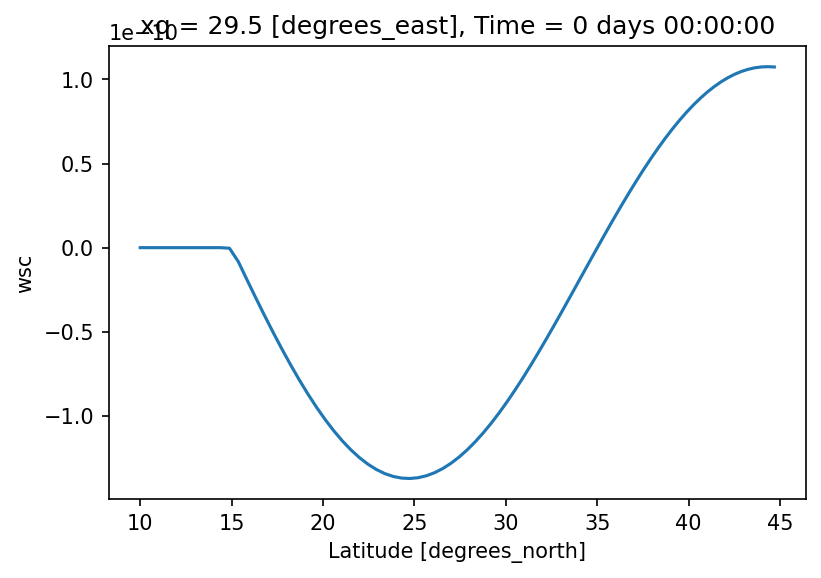

In [769]:
forcing.wsc.isel(xq=-1).plot()

## Statistics

In [770]:
stats = xr.open_dataset(os.path.join(expdir, 'OUTPUT/ocean.stats.nc'))
stats

<xarray.Dataset>
Dimensions:        (Layer: 2, Interface: 3, Time: 36001)
Coordinates:
  * Layer          (Layer) float64 1.035e+03 1.036e+03
  * Interface      (Interface) float64 1.034e+03 1.036e+03 1.037e+03
  * Time           (Time) timedelta64[ns] 0 days 1 days ... 36000 days
Data variables:
    Ntrunc         (Time) float64 ...
    En             (Time) float64 ...
    APE            (Time, Interface) float64 ...
    KE             (Time, Layer) float64 ...
    H0             (Time, Interface) float64 ...
    Mass_lay       (Time, Layer) float64 ...
    Mass           (Time) float64 ...
    Mass_chg       (Time) float64 ...
    Mass_anom      (Time) float64 ...
    max_CFL_trans  (Time) float64 ...
    max_CFL_lin    (Time) float64 ...
Attributes:
    filename:  ./ocean.stats.nc

## Prognostic variables

In [771]:
prog = xr.open_mfdataset(os.path.join(expdir, 'OUTPUT/ave_prog*.nc'), decode_times=False)
prog

<xarray.Dataset>
Dimensions:     (xq: 61, yh: 81, zl: 2, time: 100, nv: 2, xh: 60, yq: 82, zi: 3)
Coordinates:
  * xq          (xq) float64 0.0 0.5 1.0 1.5 2.0 ... 28.0 28.5 29.0 29.5 30.0
  * yh          (yh) float64 10.25 10.74 11.23 11.72 ... 43.79 44.15 44.5 44.86
  * zl          (zl) float64 1.035e+03 1.036e+03
  * time        (time) float64 180.0 540.0 900.0 ... 3.546e+04 3.582e+04
  * nv          (nv) float64 1.0 2.0
  * xh          (xh) float64 0.25 0.75 1.25 1.75 ... 28.25 28.75 29.25 29.75
  * yq          (yq) float64 10.0 10.49 10.98 11.47 ... 43.97 44.33 44.68 45.04
  * zi          (zi) float64 1.034e+03 1.036e+03 1.037e+03
Data variables:
    u           (time, zl, yh, xq) float32 dask.array<chunksize=(10, 2, 81, 61), meta=np.ndarray>
    v           (time, zl, yq, xh) float32 dask.array<chunksize=(10, 2, 82, 60), meta=np.ndarray>
    h           (time, zl, yh, xh) float64 dask.array<chunksize=(10, 2, 81, 60), meta=np.ndarray>
    e           (time, zi, yh, xh) float32 dask.array<chunksize=(10, 3, 81, 60), meta=np.ndarray>
    average_T1  (time) float64 dask.array<chunksize=(10,), meta=np.ndarray>
    average_T2  (time) float64 dask.array<chunksize=(10,), meta=np.ndarray>
    average_DT  (time) float64 dask.array<chunksize=(10,), meta=np.ndarray>
    time_bnds   (time, nv) float64 dask.array<chunksize=(10, 2), meta=np.ndarray>
Attributes:
    NumFilesInSet:  1
    title:          MOM Experiment
    grid_type:      regular
    grid_tile:      N/A

"e" is 4-dimensional. netcdf files and objects are index [n,k,j,i] for the time-, vertical-, meridional-, zonal-axes.

Let's take a quick look at the first record [n=0] of the top interface [k=0]. 

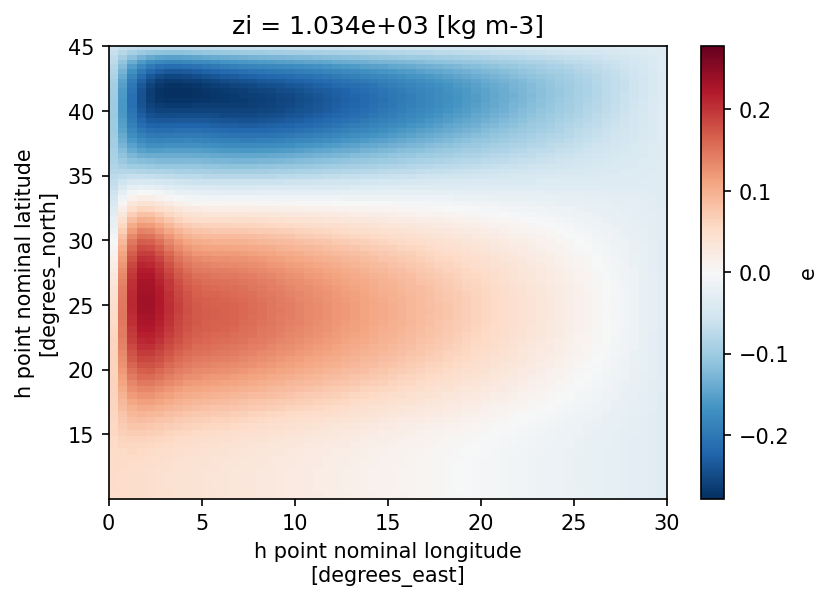

In [772]:
pc = (prog.e.isel(time=tavg, zi=0)).mean(dim='time').plot()

## Snapshots

In [773]:
snapshot = xr.open_mfdataset(os.path.join(expdir, 'OUTPUT/prog_*.nc'), decode_times=False)
snapshot

<xarray.Dataset>
Dimensions:  (xq: 61, yh: 81, zl: 2, time: 100, xh: 60, yq: 82, zi: 3)
Coordinates:
  * xq       (xq) float64 0.0 0.5 1.0 1.5 2.0 2.5 ... 28.0 28.5 29.0 29.5 30.0
  * yh       (yh) float64 10.25 10.74 11.23 11.72 ... 43.79 44.15 44.5 44.86
  * zl       (zl) float64 1.035e+03 1.036e+03
  * time     (time) float64 360.0 720.0 1.08e+03 ... 3.528e+04 3.564e+04 3.6e+04
  * xh       (xh) float64 0.25 0.75 1.25 1.75 2.25 ... 28.25 28.75 29.25 29.75
  * yq       (yq) float64 10.0 10.49 10.98 11.47 ... 43.97 44.33 44.68 45.04
  * zi       (zi) float64 1.034e+03 1.036e+03 1.037e+03
Data variables:
    u        (time, zl, yh, xq) float32 dask.array<chunksize=(10, 2, 81, 61), meta=np.ndarray>
    v        (time, zl, yq, xh) float32 dask.array<chunksize=(10, 2, 82, 60), meta=np.ndarray>
    h        (time, zl, yh, xh) float64 dask.array<chunksize=(10, 2, 81, 60), meta=np.ndarray>
    e        (time, zi, yh, xh) float32 dask.array<chunksize=(10, 3, 81, 60), meta=np.ndarray>
Attributes:
    NumFilesInSet:  1
    title:          MOM Experiment
    grid_type:      regular
    grid_tile:      N/A

## Continuity

In [774]:
cont = xr.open_mfdataset(os.path.join(expdir, 'OUTPUT/cont*.nc'), decode_times=False)
cont

<xarray.Dataset>
Dimensions:     (xq: 61, yh: 81, zl: 2, time: 100, nv: 2, xh: 60, yq: 82)
Coordinates:
  * xq          (xq) float64 0.0 0.5 1.0 1.5 2.0 ... 28.0 28.5 29.0 29.5 30.0
  * yh          (yh) float64 10.25 10.74 11.23 11.72 ... 43.79 44.15 44.5 44.86
  * zl          (zl) float64 1.035e+03 1.036e+03
  * time        (time) float64 180.0 540.0 900.0 ... 3.546e+04 3.582e+04
  * nv          (nv) float64 1.0 2.0
  * xh          (xh) float64 0.25 0.75 1.25 1.75 ... 28.25 28.75 29.25 29.75
  * yq          (yq) float64 10.0 10.49 10.98 11.47 ... 43.97 44.33 44.68 45.04
Data variables:
    uh          (time, zl, yh, xq) float32 dask.array<chunksize=(10, 2, 81, 61), meta=np.ndarray>
    vh          (time, zl, yq, xh) float32 dask.array<chunksize=(10, 2, 82, 60), meta=np.ndarray>
    uhGM        (time, zl, yh, xq) float32 dask.array<chunksize=(10, 2, 81, 61), meta=np.ndarray>
    vhGM        (time, zl, yq, xh) float32 dask.array<chunksize=(10, 2, 82, 60), meta=np.ndarray>
    average_T1  (time) float64 dask.array<chunksize=(10,), meta=np.ndarray>
    average_T2  (time) float64 dask.array<chunksize=(10,), meta=np.ndarray>
    average_DT  (time) float64 dask.array<chunksize=(10,), meta=np.ndarray>
    time_bnds   (time, nv) float64 dask.array<chunksize=(10, 2), meta=np.ndarray>
Attributes:
    NumFilesInSet:  1
    title:          MOM Experiment
    grid_type:      regular
    grid_tile:      N/A

# Calculations

## Instantenous vorticity

In [775]:
snapshot['zeta'] = (grid_op.diff(snapshot.v*grid.dyCv, 'X') - grid_op.diff(snapshot.u*grid.dxCu, 'Y'))/grid.Aq

## Streamfunctions

In [776]:
psi = grid_op.cumsum(cont.vh.isel(time=tavg).mean(dim='time'), axis='X', to='outer', boundary='fill')/1e6
psiB = psi.sum(dim='zl')

## TWA quantities

### Thicknesses and velocities

In [777]:
h_at_u = grid_op.interp(prog.h.isel(time=tavg).mean(dim='time'), 'X').where(grid.maskU > 0)
h_at_v = grid_op.interp(prog.h.isel(time=tavg).mean(dim='time'), 'Y').where(grid.maskV > 0)
h_at_q = grid_op.interp(h_at_u.fillna(0), 'Y').where(grid.maskZ > 0)


# TWA velocities
uhat = cont.uh.isel(time=tavg).mean(dim='time')/h_at_u/grid.dyCuo
vhat = cont.vh.isel(time=tavg).mean(dim='time')/h_at_v/grid.dxCvo

In [778]:
twa = xr.Dataset({'h': prog.h.isel(time=tavg).mean(dim='time'), 'h_at_u': h_at_u, 'h_at_v': h_at_v, 'h_at_q': h_at_q,
                  'uhat': uhat, 'vhat': vhat})
twa

<xarray.Dataset>
Dimensions:  (yh: 81, zl: 2, xh: 60, xq: 61, yq: 82)
Coordinates:
  * yh       (yh) float64 10.25 10.74 11.23 11.72 ... 43.79 44.15 44.5 44.86
  * zl       (zl) float64 1.035e+03 1.036e+03
  * xh       (xh) float64 0.25 0.75 1.25 1.75 2.25 ... 28.25 28.75 29.25 29.75
  * xq       (xq) float64 0.0 0.5 1.0 1.5 2.0 2.5 ... 28.0 28.5 29.0 29.5 30.0
    Time     timedelta64[ns] 00:00:00
  * yq       (yq) float64 10.0 10.49 10.98 11.47 ... 43.97 44.33 44.68 45.04
Data variables:
    h        (zl, yh, xh) float64 dask.array<chunksize=(2, 81, 60), meta=np.ndarray>
    h_at_u   (zl, yh, xq) float64 dask.array<chunksize=(2, 81, 1), meta=np.ndarray>
    h_at_v   (zl, yq, xh) float64 dask.array<chunksize=(2, 1, 60), meta=np.ndarray>
    h_at_q   (zl, yq, xq) float64 dask.array<chunksize=(2, 1, 1), meta=np.ndarray>
    uhat     (zl, yh, xq) float64 dask.array<chunksize=(2, 81, 1), meta=np.ndarray>
    vhat     (zl, yq, xh) float64 dask.array<chunksize=(2, 1, 60), meta=np.ndarray>

### Vorticity

The "vorticity" field appearing in the TWA is 

$$
\zeta^\sharp = \frac{1}{\Delta x \Delta y}\left[\delta_i(\Delta y \hat{v})  - \delta_j(\Delta x\hat{u})\right],
$$

where the hats are designate thickness-weighted quantities. This is not the TWA of the vorticity, hence the sharp sign.

The PV is

$$
\Pi^\sharp = \frac{\zeta^\sharp + f}{\bar{h}}.
$$

In [779]:
twa['zeta'] = (grid_op.diff(twa.vhat*grid.dyCv, 'X') - grid_op.diff(twa.uhat*grid.dxCu, 'Y'))/grid.Aq
twa['Pi'] = ((twa.zeta + grid.fq)/twa.h_at_q).where(twa.h_at_q > 1)

# Plot

## Convergence

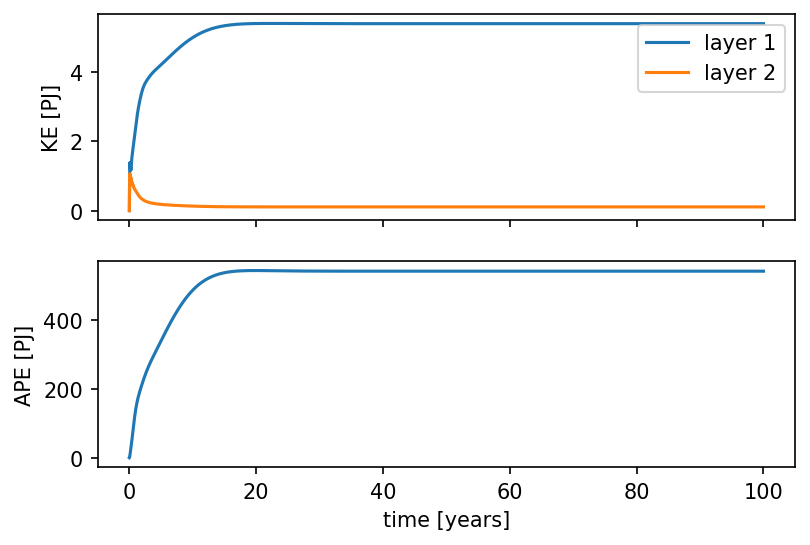

In [780]:
years = np.arange(len(stats.Time))/360

fig, axs = plt.subplots(nrows=2, sharex=True)

ax = axs[0]
ax.plot(years, stats.KE.isel(Layer=0)/1e15, label='layer 1')
ax.plot(years, stats.KE.isel(Layer=1)/1e15, label='layer 2')
ax.legend()
ax.set_ylabel('KE [PJ]')

ax = axs[1]
ax.plot(years, stats.APE.isel(Interface=1)/1e15)
ax.set_ylabel('APE [PJ]')
ax.set_xlabel('time [years]')

savefig(fig, 'energy')

## SSH

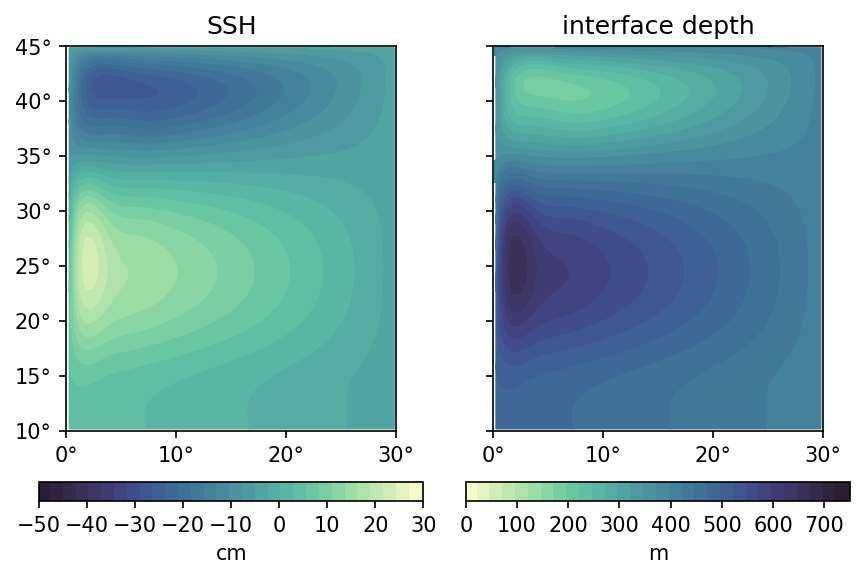

In [781]:
fig, axs = plt.subplots(ncols=2, sharex=True, sharey=True)


ax = axs[0]
setup_plan_plot(ax)
fld = 100*prog.e.isel(zi=0).isel(time=tavg).mean(dim='time')
vmax =  30
vmin = -50
levels = np.linspace(vmin, vmax, 31)
cs = ax.contourf(fld.xh, fld.yh, fld, levels=levels, vmin=vmin, vmax=vmax, cmap='cmo.deep_r')
# This is the fix for the white lines between contour levels
for c in cs.collections:
    c.set_edgecolor('face')
ax.set_aspect(1)
ax.set_title('SSH')
fig.colorbar(cs, ax=ax, orientation='horizontal', ticks=np.arange(-50, 31, 10), pad=.1, label='cm').solids.set_edgecolor('face')

ax = axs[1]
setup_plan_plot(ax)
fld = -prog.e.isel(zi=1).isel(time=tavg).mean(dim='time')
# vmax = float(fld.max())
# vmin = float(fld.min())
vmax = 750
vmin = 0
levels = np.linspace(vmin, vmax, 31)
cs = ax.contourf(fld.xh, fld.yh, fld, levels=levels, vmin=vmin, vmax=vmax, cmap='cmo.deep')
# This is the fix for the white lines between contour levels
for c in cs.collections:
    c.set_edgecolor('face')
ax.set_aspect(1)
ax.set_title('interface depth')
fig.colorbar(cs, ax=ax, orientation='horizontal', pad=.1, label='m').solids.set_edgecolor('face')

fig.tight_layout()
savefig(fig, 'ssh')

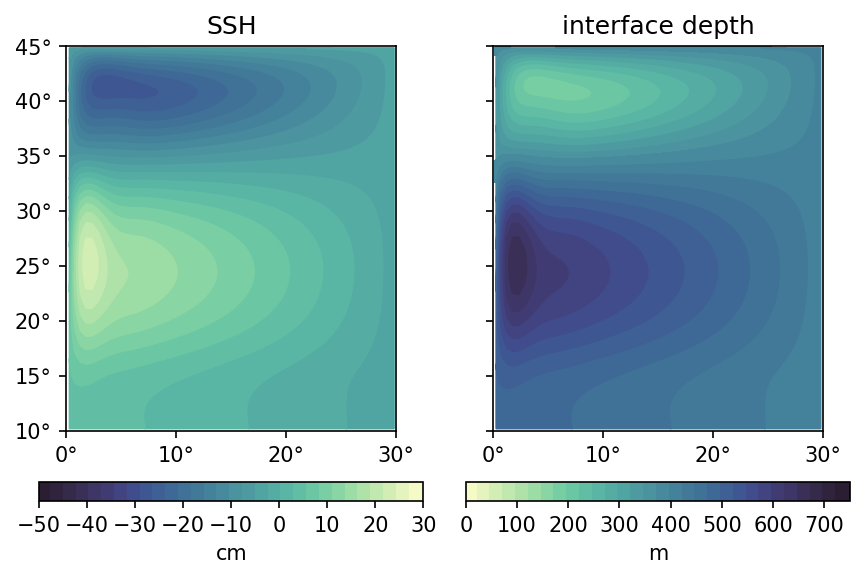

In [782]:
fig, axs = plt.subplots(ncols=2, sharex=True, sharey=True)


ax = axs[0]
setup_plan_plot(ax)
fld = 100*snapshot.e.isel(zi=0).isel(time=-1)
vmax =  30
vmin = -50
levels = np.linspace(vmin, vmax, 31)
cs = ax.contourf(fld.xh, fld.yh, fld, levels=levels, vmin=vmin, vmax=vmax, cmap='cmo.deep_r')
# This is the fix for the white lines between contour levels
for c in cs.collections:
    c.set_edgecolor('face')
ax.set_aspect(1)
ax.set_title('SSH')
fig.colorbar(cs, ax=ax, orientation='horizontal', ticks=np.arange(-50, 31, 10), pad=.1, label='cm').solids.set_edgecolor('face')

ax = axs[1]
setup_plan_plot(ax)
fld = -snapshot.e.isel(zi=1).isel(time=-1)
# vmax = float(fld.max())
# vmin = float(fld.min())
vmax = 750
vmin = 0
levels = np.linspace(vmin, vmax, 31)
cs = ax.contourf(fld.xh, fld.yh, fld, levels=levels, vmin=vmin, vmax=vmax, cmap='cmo.deep')
# This is the fix for the white lines between contour levels
for c in cs.collections:
    c.set_edgecolor('face')
ax.set_aspect(1)
ax.set_title('interface depth')
fig.colorbar(cs, ax=ax, orientation='horizontal', pad=.1, label='m').solids.set_edgecolor('face')

fig.tight_layout()
savefig(fig, 'snapshot_ssh')

## Vorticity

/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/dask/utils.py:35: RuntimeWarning: All-NaN slice encountered
  return func(*args, **kwargs)
/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/dask/core.py:119: RuntimeWarning: All-NaN slice encountered
  return func(*(_execute_task(a, cache) for a in args))
/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/dask/utils.py:35: RuntimeWarning: All-NaN slice encountered
  return func(*args, **kwargs)
/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/dask/core.py:119: RuntimeWarning: All-NaN slice encountered
  return func(*(_execute_task(a, cache) for a in args))


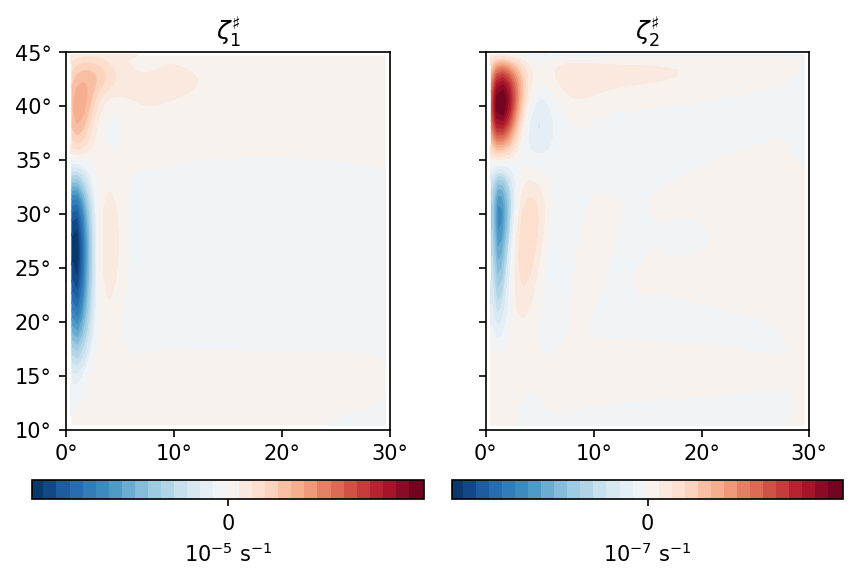

In [783]:
fig, axs = plt.subplots(ncols=2, sharex=True, sharey=True)


ax = axs[0]
setup_plan_plot(ax)
fld = 1e5*twa.zeta.isel(zl=0)
vmax =  float(np.abs(fld).max())
vmin = -vmax
levels = np.linspace(vmin, vmax, 31)
cs = ax.contourf(fld.xq, fld.yq, fld, levels=levels, vmin=vmin, vmax=vmax, cmap='RdBu_r')
# This is the fix for the white lines between contour levels
for c in cs.collections:
    c.set_edgecolor('face')
ax.set_aspect(1)
ax.set_title(r'$\zeta_1^\sharp$')
fig.colorbar(cs, ax=ax, orientation='horizontal', ticks=integer_ticks(vmax, spacing=1), 
             pad=.1, label=r'$10^{-5}$ s$^{-1}$').solids.set_edgecolor('face')

ax = axs[1]
setup_plan_plot(ax)
fld = 1e7*twa.zeta.isel(zl=1)
vmax =  float(np.abs(fld).max())
vmin = -vmax
levels = np.linspace(vmin, vmax, 31)
cs = ax.contourf(fld.xq, fld.yq, fld, levels=levels, vmin=vmin, vmax=vmax, cmap='RdBu_r')
# This is the fix for the white lines between contour levels
for c in cs.collections:
    c.set_edgecolor('face')
ax.set_aspect(1)
ax.set_title(r'$\zeta_2^\sharp$')
fig.colorbar(cs, ax=ax, orientation='horizontal', ticks=integer_ticks(vmax, spacing=2), 
             pad=.1, label=r'$10^{-7}$ s$^{-1}$').solids.set_edgecolor('face')

fig.tight_layout()
savefig(fig, 'twa_vorticity')

/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/dask/utils.py:35: RuntimeWarning: All-NaN slice encountered
  return func(*args, **kwargs)
/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/dask/core.py:119: RuntimeWarning: All-NaN slice encountered
  return func(*(_execute_task(a, cache) for a in args))
/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/dask/utils.py:35: RuntimeWarning: All-NaN slice encountered
  return func(*args, **kwargs)
/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/dask/core.py:119: RuntimeWarning: All-NaN slice encountered
  return func(*(_execute_task(a, cache) for a in args))


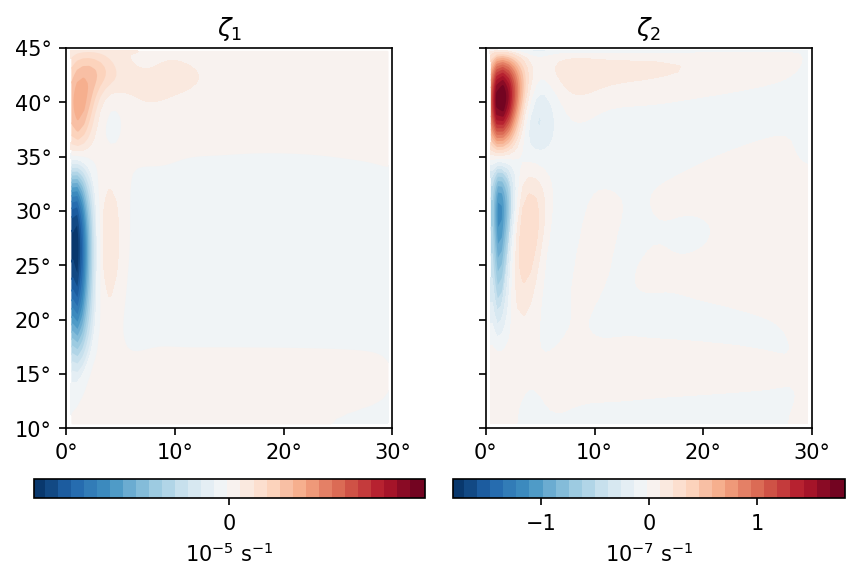

In [784]:
fig, axs = plt.subplots(ncols=2, sharex=True, sharey=True)


ax = axs[0]
setup_plan_plot(ax)
fld = 1e5*snapshot.zeta.isel(zl=0, time=-1)
vmax =  float(np.abs(fld).max())
vmin = -vmax
levels = np.linspace(vmin, vmax, 31)
cs = ax.contourf(fld.xq, fld.yq, fld, levels=levels, vmin=vmin, vmax=vmax, cmap='RdBu_r')
# This is the fix for the white lines between contour levels
for c in cs.collections:
    c.set_edgecolor('face')
ax.set_aspect(1)
ax.set_title(r'$\zeta_1$')
fig.colorbar(cs, ax=ax, orientation='horizontal', ticks=integer_ticks(vmax, spacing=1), 
             pad=.1, label=r'$10^{-5}$ s$^{-1}$').solids.set_edgecolor('face')

ax = axs[1]
setup_plan_plot(ax)
fld = 1e7*snapshot.zeta.isel(zl=1, time=-1)
vmax =  float(np.abs(fld).max())
vmin = -vmax
levels = np.linspace(vmin, vmax, 31)
cs = ax.contourf(fld.xq, fld.yq, fld, levels=levels, vmin=vmin, vmax=vmax, cmap='RdBu_r')
# This is the fix for the white lines between contour levels
for c in cs.collections:
    c.set_edgecolor('face')
ax.set_aspect(1)
ax.set_title(r'$\zeta_2$')
fig.colorbar(cs, ax=ax, orientation='horizontal', ticks=integer_ticks(vmax, nticks=4), 
             pad=.1, label=r'$10^{-7}$ s$^{-1}$').solids.set_edgecolor('face')

fig.tight_layout()
savefig(fig, 'vorticity_snapshot')

## Streamfunctions

### Barotropic

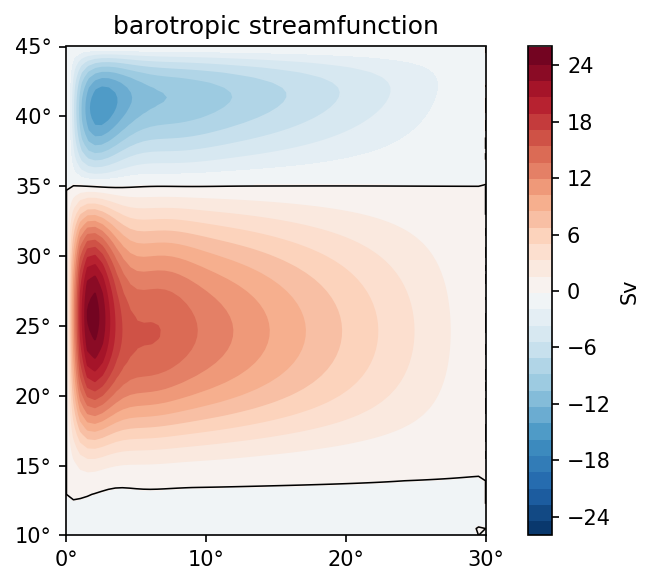

In [785]:
vmax = np.ceil(float(np.abs(psiB).max()))
vmin = -vmax
levels = np.linspace(vmin, vmax, 31)

fig, ax = plt.subplots()
setup_plan_plot(ax)
cs = ax.contourf(psiB.xq, psiB.yq, psiB, levels=levels, vmin=vmin, vmax=vmax, cmap='RdBu_r')
# This is the fix for the white lines between contour levels
for c in cs.collections:
    c.set_edgecolor('face')
ax.contour(psiB.xq, psiB.yq, psiB, levels=[0], colors='k', linewidths=.75)
# ax.contour(grid.xh, grid.yh, twa.h.isel(zl=0), levels=[10], colors='k')
ax.set_aspect(1)
fig.colorbar(cs, ax=ax, ticks=integer_ticks(vmax, nticks=5), label='Sv').solids.set_edgecolor('face')
ax.set_title('barotropic streamfunction')

fig.tight_layout()
savefig(fig, 'barotropic_streamfunction')

### Layerwise

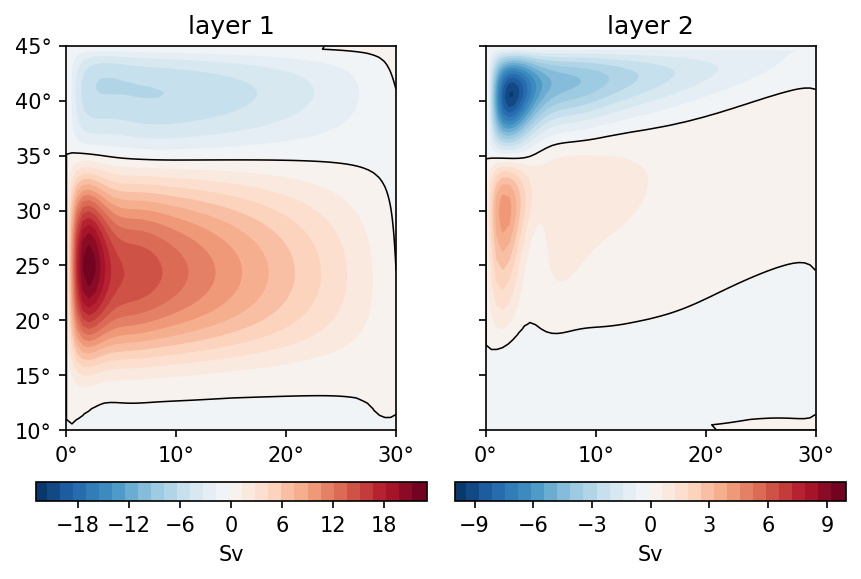

In [786]:
fig, axs = plt.subplots(ncols=2, sharex=True, sharey=True)

for zl, ax in enumerate(axs):
    setup_plan_plot(ax)
    vmax = np.ceil(float(np.abs(psi.isel(zl=zl)).max()))
    vmin = -vmax
    levels = np.linspace(vmin, vmax, 31)
    cs = ax.contourf(psi.xq, psi.yq, psi.isel(zl=zl), levels=levels, vmin=vmin, vmax=vmax, cmap='RdBu_r')
    # This is the fix for the white lines between contour levels
    for c in cs.collections:
        c.set_edgecolor('face')
    ax.contour(psi.xq, psi.yq, psi.isel(zl=zl), levels=[0], colors='k', linewidths=.75)
    fig.colorbar(cs, ax=ax, ticks=integer_ticks(vmax, nticks=4), orientation='horizontal', 
                 label='Sv', pad=.1).solids.set_edgecolor('face')
    ax.set_title('layer ' + str(zl+1))

fig.tight_layout()
savefig(fig, 'layer_streamfunctions')

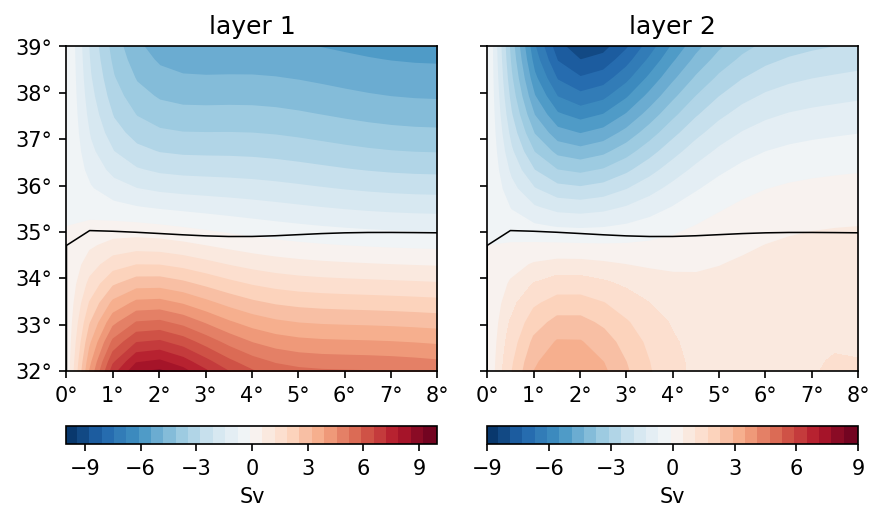

In [787]:
fig, axs = plt.subplots(ncols=2, sharex=True, sharey=True)

# The contour is the zero of the barotropic streamfunction

fld = psi.sel(xq=slice(recirc_lon[0], recirc_lon[1]+.5), yq=slice(recirc_lat[0]-.5, recirc_lat[1]+.5))

for zl, ax in enumerate(axs):
    setup_plan_plot(ax)
    vmax = np.ceil(float(np.abs(fld.isel(zl=zl)).max()))
    vmin = -vmax
    levels = np.linspace(vmin, vmax, 31)
    cs = ax.contourf(fld.xq, fld.yq, fld.isel(zl=zl), levels=levels, vmin=vmin, vmax=vmax, cmap='RdBu_r')
    # This is the fix for the white lines between contour levels
    for c in cs.collections:
        c.set_edgecolor('face')
    ax.contour(psi.xq, psi.yq, psi.sum(dim='zl'), levels=[0], colors='k', linewidths=.75)
    fig.colorbar(cs, ax=ax, ticks=integer_ticks(vmax, nticks=4), orientation='horizontal', 
                 label='Sv', pad=.1).solids.set_edgecolor('face')
    ax.set_title('layer ' + str(zl+1))

axs[0].set_xlim(recirc_lon)
axs[0].set_ylim(recirc_lat)
axs[0].set_aspect(1)
xticks = np.arange(recirc_lon[0], recirc_lon[1]+.25, 1)
yticks = np.arange(recirc_lat[0], recirc_lat[1]+.25, 1)
axs[0].set_xticks(xticks, labels=lonFormatter.format(xticks))
axs[0].set_yticks(yticks, labels=latFormatter.format(yticks))
    
fig.tight_layout()
savefig(fig, 'layer_streamfunctions_recirc')

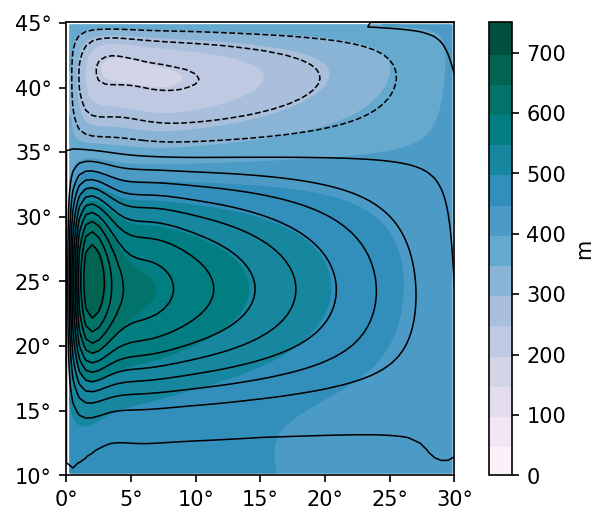

In [788]:
vmin = 0
vmax = 750
levels = np.arange(vmin, vmax+1, 50)

fig, ax = plt.subplots()

h = twa.h.isel(zl=0)
cs = ax.contourf(h.xh, h.yh, h, levels=levels, vmin=vmin, vmax=vmax, cmap='PuBuGn')
# This is the fix for the white lines between contour levels
for c in cs.collections:
    c.set_edgecolor('face')
ax.contour(psi.xq, psi.yq, psi.isel(zl=0), levels=np.arange(-20, 21, 2), colors='k', linewidths=.75)
# ax.contour(psi.xq, psi.yq, psi.isel(zl=1), levels=np.arange(-20, 21, 2), colors='k', linewidths=1)
# ax.contour(lon, lat, psi2, levels=np.arange(-20, 21, 2), colors='k', linewidths=1)
# ax.plot(np.rad2deg(λo), lat, ls='-', color='tab:gray', lw=2)

fig.colorbar(cs, label='m').solids.set_edgecolor('face')

yticks = np.arange(10, 46, 5)
latFormatter = pw.plt.LatitudeFormatter(direction_labels=False)
ax.set_yticks(yticks)
ax.set_yticklabels(latFormatter.format(yticks))

xticks = np.arange(0, 31, 5)
ax.set_xticks(xticks)
ax.set_xticklabels(lonFormatter.format(xticks))

ax.set_aspect(1)

savefig(fig, 'thickness_psi_mom')

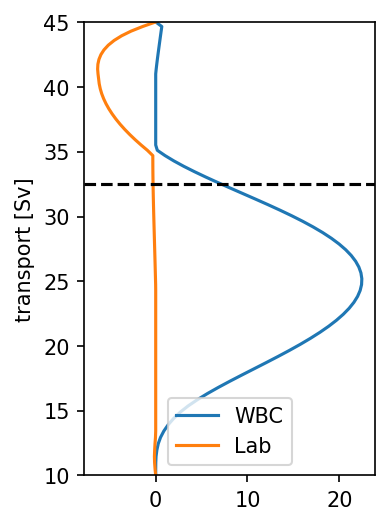

In [789]:
T_wbc = psi.isel(zl=0).max(dim='xq')
T_lab = psi.isel(zl=0).min(dim='xq')

fig, ax = plt.subplots(figsize=(2.5,4))

ax.plot(T_wbc, T_wbc.yq, label='WBC')
ax.plot(T_lab, T_wbc.yq, label='Lab')
ax.set_ylabel('transport [Sv]')

ax.set_ylim([10, 45])
ax.legend(loc='lower center')
ax.axhline(32.5, color='k', ls='--')

savefig(fig, 'outcrop_transports_mom')

## Velocities

### Layerwise

In [790]:
u = 100*grid_op.interp(twa.uhat.fillna(0), 'X')
v = 100*grid_op.interp(twa.vhat.fillna(0), 'Y')

speed = np.sqrt(u**2 + v**2)

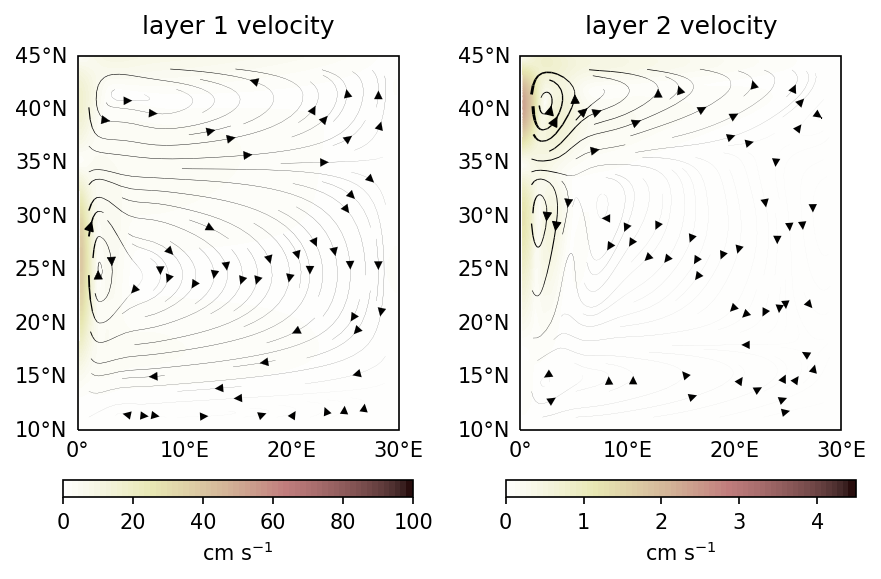

In [791]:
fig, axs = plt.subplots(ncols=2, sharex=True, sharey=True, subplot_kw={'projection': ccrs.PlateCarree()})
data_projection = ccrs.PlateCarree()

vm = [100, 4.5]
cticks = [np.arange(0, 101, 20), np.arange(0, 5, 1)]
for zl in range(2):
    ax = axs[zl]
    setup_cartopy_plot(ax)
    vmax = vm[zl]
    vmin = 0
    levels = np.linspace(vmin, vmax, 64)

    lw = (5*speed.isel(zl=zl) / vmax).values

    cs = ax.contourf(grid.xh.values, grid.yh.values, speed.isel(zl=zl), levels, 
                          vmin=vmin, vmax=vmax, cmap='pink_r',
                          transform=data_projection)
    for c in cs.collections:
        c.set_edgecolor('face')
    sp = ax.streamplot(grid.xh.values, grid.yh.values, u.isel(zl=zl).values, v.isel(zl=zl).values,
                  transform=data_projection, maxlength=16, color='k', linewidth=lw)
    
    fig.colorbar(cs, ax=ax, orientation='horizontal', ticks=cticks[zl], label=r'cm s$^{-1}$', pad=.1).solids.set_edgecolor('face')

axs[0].set_title('layer 1 velocity')
axs[1].set_title('layer 2 velocity')
    
fig.tight_layout()
# I get "ValueError: Can only output finite numbers in PDF" from the PDF backend if I try to save these as PDFs.
savefig(fig, 'velocities', pdf=False)

In [792]:
u = 100*grid_op.interp(snapshot.u.isel(time=-1).fillna(0), 'X')
v = 100*grid_op.interp(snapshot.v.isel(time=-1).fillna(0), 'Y')

speed = np.sqrt(u**2 + v**2)

In [793]:
speed.isel(zl=1).max().values

array(2.3083894, dtype=float32)

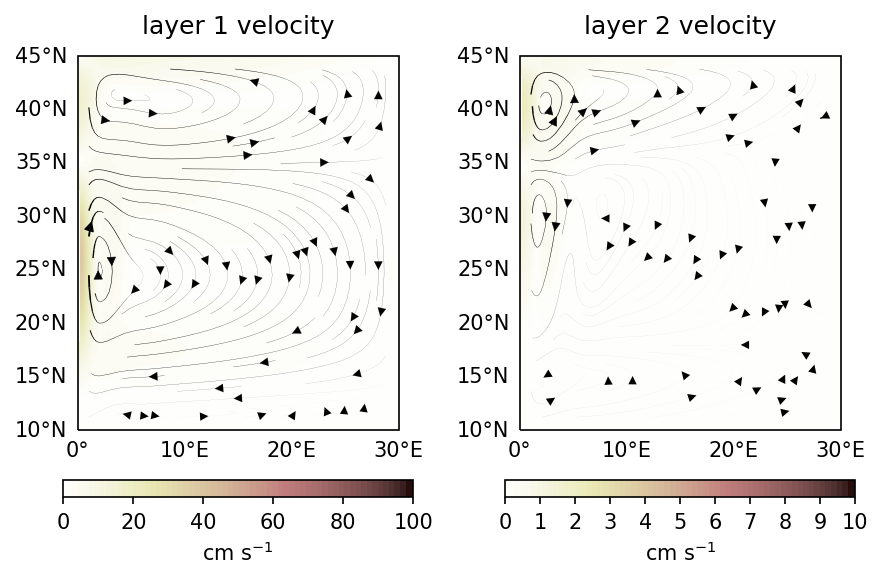

In [794]:
fig, axs = plt.subplots(ncols=2, sharex=True, sharey=True, subplot_kw={'projection': ccrs.PlateCarree()})
data_projection = ccrs.PlateCarree()

vm = [100, 10]
cticks = [np.arange(0, vm[0]+1, 20), np.arange(0, vm[1]+1, 1)]
for zl in range(2):
    ax = axs[zl]
    setup_cartopy_plot(ax)
    vmax = vm[zl]
    vmin = 0
    levels = np.linspace(vmin, vmax, 64)

    lw = (5*speed.isel(zl=zl) / vmax).values

    cs = ax.contourf(grid.xh.values, grid.yh.values, speed.isel(zl=zl), levels, 
                          vmin=vmin, vmax=vmax, cmap='pink_r',
                          transform=data_projection)
    for c in cs.collections:
        c.set_edgecolor('face')
    sp = ax.streamplot(grid.xh.values, grid.yh.values, u.isel(zl=zl).values, v.isel(zl=zl).values,
                  transform=data_projection, maxlength=16, color='k', linewidth=lw)
    
    fig.colorbar(cs, ax=ax, orientation='horizontal', ticks=cticks[zl], label=r'cm s$^{-1}$', pad=.1).solids.set_edgecolor('face')

axs[0].set_title('layer 1 velocity')
axs[1].set_title('layer 2 velocity')
    
fig.tight_layout()
# I get "ValueError: Can only output finite numbers in PDF" from the PDF backend if I try to save these as PDFs.
savefig(fig, 'snapshot_velocities', pdf=False)

### Barotropic

In [795]:
U = 100*grid_op.interp(cont.uh.isel(time=tavg).mean(dim='time').sum(dim='zl').fillna(0)/grid.dyCu, 'X')/grid.D
V = 100*grid_op.interp(cont.vh.isel(time=tavg).mean(dim='time').sum(dim='zl').fillna(0)/grid.dxCv, 'Y')/grid.D

speed = np.sqrt(U**2 + V**2)

In [796]:
speed.max().values

array(5.4417723)

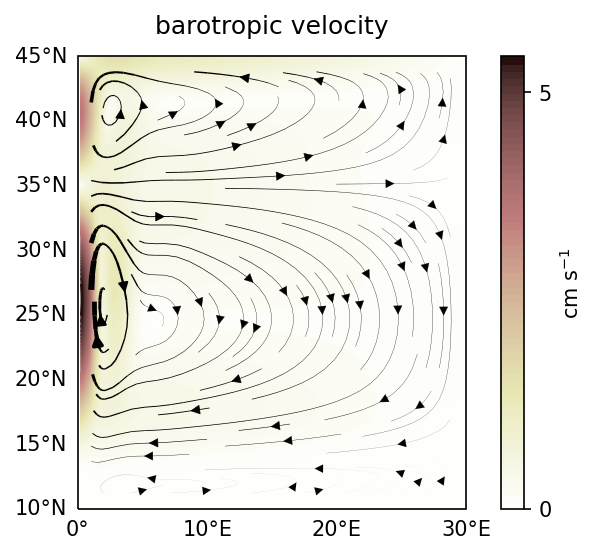

In [797]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
data_projection = ccrs.PlateCarree()

setup_cartopy_plot(ax)
vmax = float(speed.max())
vmin = 0
levels = np.linspace(vmin, vmax, 64)

lw = (5*speed / vmax).values

cs = ax.contourf(grid.xh.values, grid.yh.values, speed.values, levels, 
                      vmin=vmin, vmax=vmax, cmap='pink_r',
                      transform=data_projection)
for c in cs.collections:
    c.set_edgecolor('face')
sp = ax.streamplot(grid.xh.values, grid.yh.values, U.values, V.values,
              transform=data_projection, maxlength=16, color='k', linewidth=lw)
    
fig.colorbar(cs, ax=ax, ticks=np.arange(0, vmax+1, 5), label=r'cm s$^{-1}$').solids.set_edgecolor('face')
ax.set_title('barotropic velocity')

# I get "ValueError: Can only output finite numbers in PDF" from the PDF backend if I try to save these as PDFs.
savefig(fig, 'barotropic_velocities', pdf=False)

## PV

This is actually the inverse of the PV. Since the thickness goes to zero, the PV gets very large but it's always bounded away from zero so for sanity we plot the inverse.

/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/dask/utils.py:35: RuntimeWarning: All-NaN slice encountered
  return func(*args, **kwargs)
/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/dask/core.py:119: RuntimeWarning: All-NaN slice encountered
  return func(*(_execute_task(a, cache) for a in args))
/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/dask/utils.py:35: RuntimeWarning: All-NaN slice encountered
  return func(*args, **kwargs)
/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/dask/core.py:119: RuntimeWarning: All-NaN slice encountered
  return func(*(_execute_task(a, cache) for a in args))


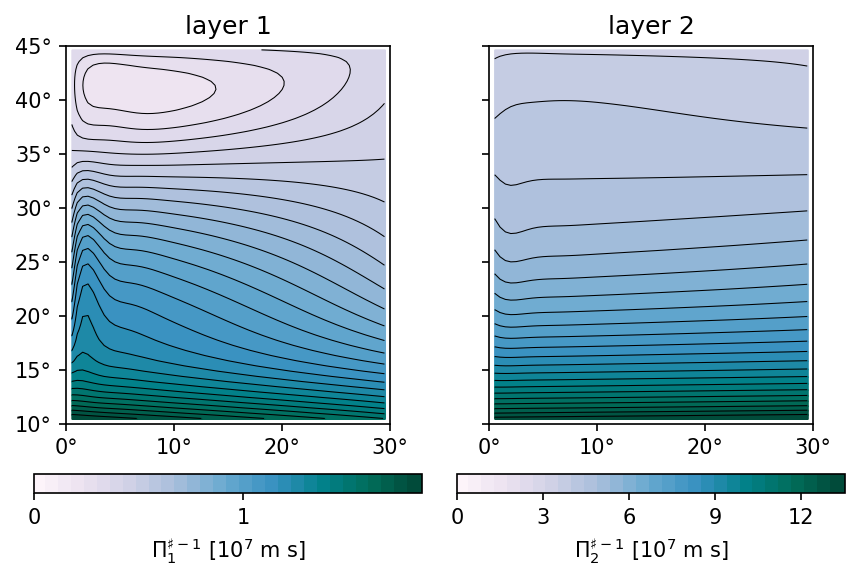

In [798]:
fig, axs = plt.subplots(ncols=2, sharex=True, sharey=True)

fld = 1e-7*(1/twa.Pi)
vmin = 0

for zl, ax in enumerate(axs):
    setup_plan_plot(ax)
    vmax = float(fld.isel(zl=zl).max())
    levels = np.linspace(vmin, vmax, 31)
    cs = ax.contourf(fld.xq, fld.yq, fld.isel(zl=zl), levels=levels, vmin=vmin, vmax=vmax, cmap='PuBuGn')
    for c in cs.collections:
        c.set_edgecolor('face')
    ax.contour(fld.xq, fld.yq, fld.isel(zl=zl), levels=levels, colors='k', linewidths=.5)
    cbar = fig.colorbar(cs, ax=ax, orientation='horizontal', pad=.1, label='$\Pi^{\sharp-1}_' + str(zl+1) + '$ [$10^{7}$ m s]', 
                        ticks=integer_ticks(vmax, symmetric=False, nticks=5))
    cbar.solids.set_edgecolor('face')
    ax.set_title('layer ' + str(zl+1))

# ax = axs[1]
# setup_plan_plot(ax)
# vmax = 3
# vmin = 0
# levels = np.linspace(vmin, vmax, 31)
# cs = ax.contourf(fld.xq, fld.yq, 10*fld.isel(zl=1), levels=levels, vmin=vmin, vmax=vmax, cmap='PuBuGn_r', extend='max')
# for c in cs.collections:
#     c.set_edgecolor('face')
# ax.contour(fld.xq, fld.yq, 10*fld.isel(zl=1), levels=levels, colors='k', linewidths=.5)
# cbar.solids.set_edgecolor('face')
# ax.set_title('layer 2')

fig.tight_layout()
savefig(fig, 'layer_PV')

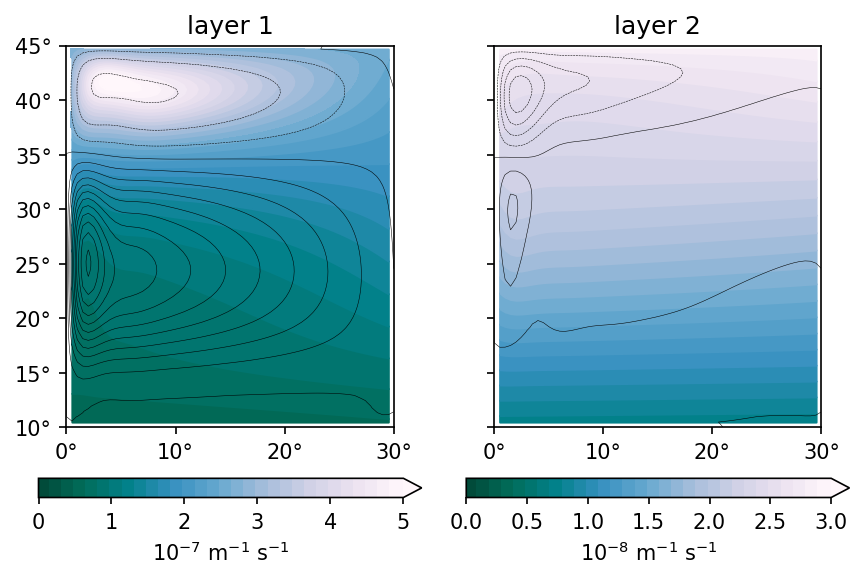

In [799]:
fig, axs = plt.subplots(ncols=2, sharex=True, sharey=True)

fld = 1e7*twa.Pi

ax = axs[0]
setup_plan_plot(ax)
vmax = 5
vmin = 0
levels = np.linspace(vmin, vmax, 31)
cs = ax.contourf(fld.xq, fld.yq, fld.isel(zl=0), levels=levels, vmin=vmin, vmax=vmax, cmap='PuBuGn_r', extend='max')
for c in cs.collections:
    c.set_edgecolor('face')
ax.contour(psi.xq, psi.yq, psi.isel(zl=0), levels=np.arange(-26, 27, 2), colors='k', linewidths=.25)
cbar = fig.colorbar(cs, ax=ax, orientation='horizontal', pad=.1, label='$10^{-7}$ m$^{-1}$ s$^{-1}$', ticks=np.arange(0, 6, 1))
cbar.solids.set_edgecolor('face')
ax.set_title('layer 1')

ax = axs[1]
setup_plan_plot(ax)
vmax = 3
vmin = 0
levels = np.linspace(vmin, vmax, 31)
cs = ax.contourf(fld.xq, fld.yq, 10*fld.isel(zl=1), levels=levels, vmin=vmin, vmax=vmax, cmap='PuBuGn_r', extend='max')
for c in cs.collections:
    c.set_edgecolor('face')
ax.contour(psi.xq, psi.yq, psi.isel(zl=1), levels=np.arange(-12, 13, 2), colors='k', linewidths=.25)
cbar = fig.colorbar(cs, ax=ax, orientation='horizontal', pad=.1, label='$10^{-8}$ m$^{-1}$ s$^{-1}$', ticks=np.arange(0, 3.5, .5))
cbar.solids.set_edgecolor('face')
ax.set_title('layer 2')

fig.tight_layout()
# savefig(fig, 'layer_steamfunction_PV')

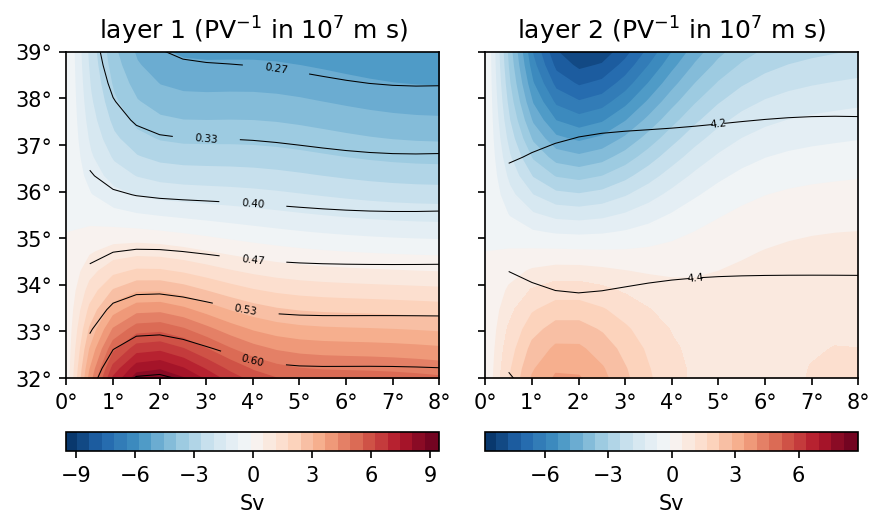

In [800]:
fig, axs = plt.subplots(ncols=2, sharex=True, sharey=True)

fld = psi.sel(xq=slice(recirc_lon[0], recirc_lon[1]+.5), yq=slice(recirc_lat[0]-.5, recirc_lat[1]+.5))
pv = 1e7*twa.Pi.sel(xq=slice(recirc_lon[0], recirc_lon[1]+.5), yq=slice(recirc_lat[0]-.5, recirc_lat[1]+.5))

ax = axs[0]
setup_plan_plot(ax)
vmax = float(np.abs(fld.isel(zl=0)).max())
vmin = -vmax
levels = np.linspace(vmin, vmax, 31)
cs = ax.contourf(fld.xq, fld.yq, fld.isel(zl=0), levels=levels, vmin=vmin, vmax=vmax, cmap='RdBu_r')
for c in cs.collections:
    c.set_edgecolor('face')
cs2 = ax.contour(pv.xq, pv.yq, 1/pv.isel(zl=0), levels=np.linspace(0, 2, 31), colors='k', linewidths=.5)
ax.clabel(cs2, fontsize=5, inline_spacing=-4, fmt='%.2f')
# ax.contour(grid.xh, grid.yh, twa.h.isel(zl=0), levels=[10], colors='k')
fig.colorbar(cs, ax=ax, orientation='horizontal', label='Sv', pad=.1, ticks=integer_ticks(vmax, 4)).solids.set_edgecolor('face')
ax.set_title('layer 1 (PV$^{-1}$ in $10^{7}$ m s)')

ax = axs[1]
setup_plan_plot(ax)
vmax = float(np.abs(fld.isel(zl=1)).max())
vmin = -vmax
levels = np.linspace(vmin, vmax, 31)
cs = ax.contourf(fld.xq, fld.yq, fld.isel(zl=1), levels=levels, vmin=vmin, vmax=vmax, cmap='RdBu_r')
for c in cs.collections:
    c.set_edgecolor('face')
cs2 = ax.contour(pv.xq, pv.yq, 1/(pv.isel(zl=1)), levels=np.linspace(0, 6, 31), colors='k', linewidths=.5)
ax.clabel(cs2, fontsize=5, inline_spacing=-7, fmt='%.1f')
# ax.contour(grid.xh, grid.yh, twa.h.isel(zl=0), levels=[10], colors='k')
fig.colorbar(cs, ax=ax, orientation='horizontal', label='Sv', pad=.1, ticks=integer_ticks(vmax, 4)).solids.set_edgecolor('face')
ax.set_title('layer 2 (PV$^{-1}$ in $10^{7}$ m s)')

axs[0].set_xlim(recirc_lon)
axs[0].set_ylim(recirc_lat)
axs[0].set_aspect(1)
xticks = np.arange(recirc_lon[0], recirc_lon[1]+.25, 1)
yticks = np.arange(recirc_lat[0], recirc_lat[1]+.25, 1)
axs[0].set_xticks(xticks, labels=lonFormatter.format(xticks))
axs[0].set_yticks(yticks, labels=latFormatter.format(yticks))
    
fig.tight_layout()
savefig(fig, 'layer_streamfunctions_recirc_pv')

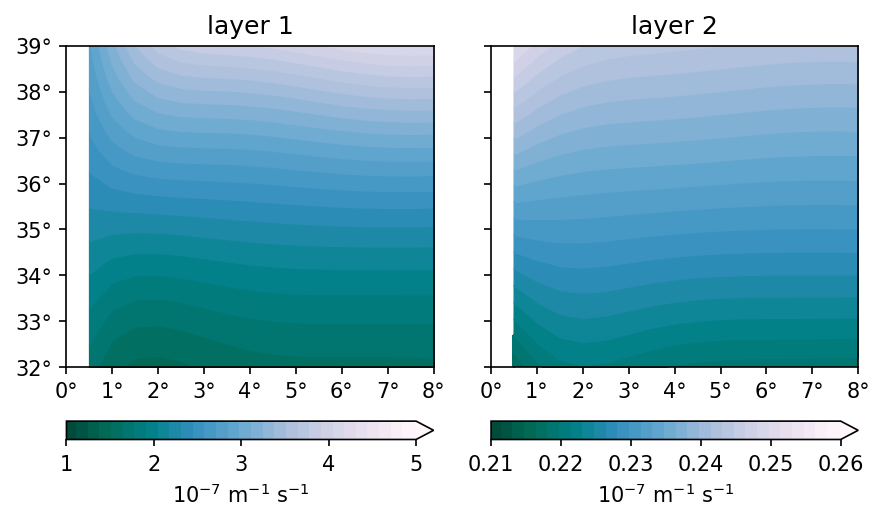

In [801]:
fig, axs = plt.subplots(ncols=2, sharex=True, sharey=True)

recirc_lon = [0, 8]
recirc_lat = [32, 39]
fld = 1e7*twa.Pi.sel(xq=slice(recirc_lon[0], recirc_lon[1]+.5), yq=slice(recirc_lat[0]-.5, recirc_lat[1]+.5))

ax = axs[0]
setup_plan_plot(ax)
vmax = 5
vmin = 1
levels = np.linspace(vmin, vmax, 31)
cs = ax.contourf(fld.xq, fld.yq, fld.isel(zl=0), levels=levels, vmin=vmin, vmax=vmax, cmap='PuBuGn_r', extend='max')
for c in cs.collections:
    c.set_edgecolor('face')
# ax.contour(psi.xq, psi.yq, psi.isel(zl=0), levels=np.arange(-26, 27, 2), colors='k', linewidths=.25)
cbar = fig.colorbar(cs, ax=ax, orientation='horizontal', pad=.1, label='$10^{-7}$ m$^{-1}$ s$^{-1}$', ticks=np.arange(1, 6, 1))
cbar.solids.set_edgecolor('face')
ax.set_title('layer 1')

ax = axs[1]
setup_plan_plot(ax)
vmax = .26
vmin = .21
levels = np.linspace(vmin, vmax, 31)
cs = ax.contourf(fld.xq, fld.yq, fld.isel(zl=1), levels=levels, vmin=vmin, vmax=vmax, cmap='PuBuGn_r', extend='max')
for c in cs.collections:
    c.set_edgecolor('face')
# ax.contour(psi.xq, psi.yq, psi.isel(zl=1), levels=np.arange(-26, 27, 2), colors='k', linewidths=.25)
cbar = fig.colorbar(cs, ax=ax, orientation='horizontal', pad=.1, label='$10^{-7}$ m$^{-1}$ s$^{-1}$', ticks=np.arange(.21, .26, .01))
cbar.solids.set_edgecolor('face')
ax.set_title('layer 2')

axs[0].set_xlim(recirc_lon)
axs[0].set_ylim(recirc_lat)
axs[0].set_aspect(1)
xticks = np.arange(recirc_lon[0], recirc_lon[1]+.25, 1)
yticks = np.arange(recirc_lat[0], recirc_lat[1]+.25, 1)
axs[0].set_xticks(xticks, labels=lonFormatter.format(xticks))
axs[0].set_yticks(yticks, labels=latFormatter.format(yticks))

fig.tight_layout()
savefig(fig, 'PV_recirc')

## WBCs

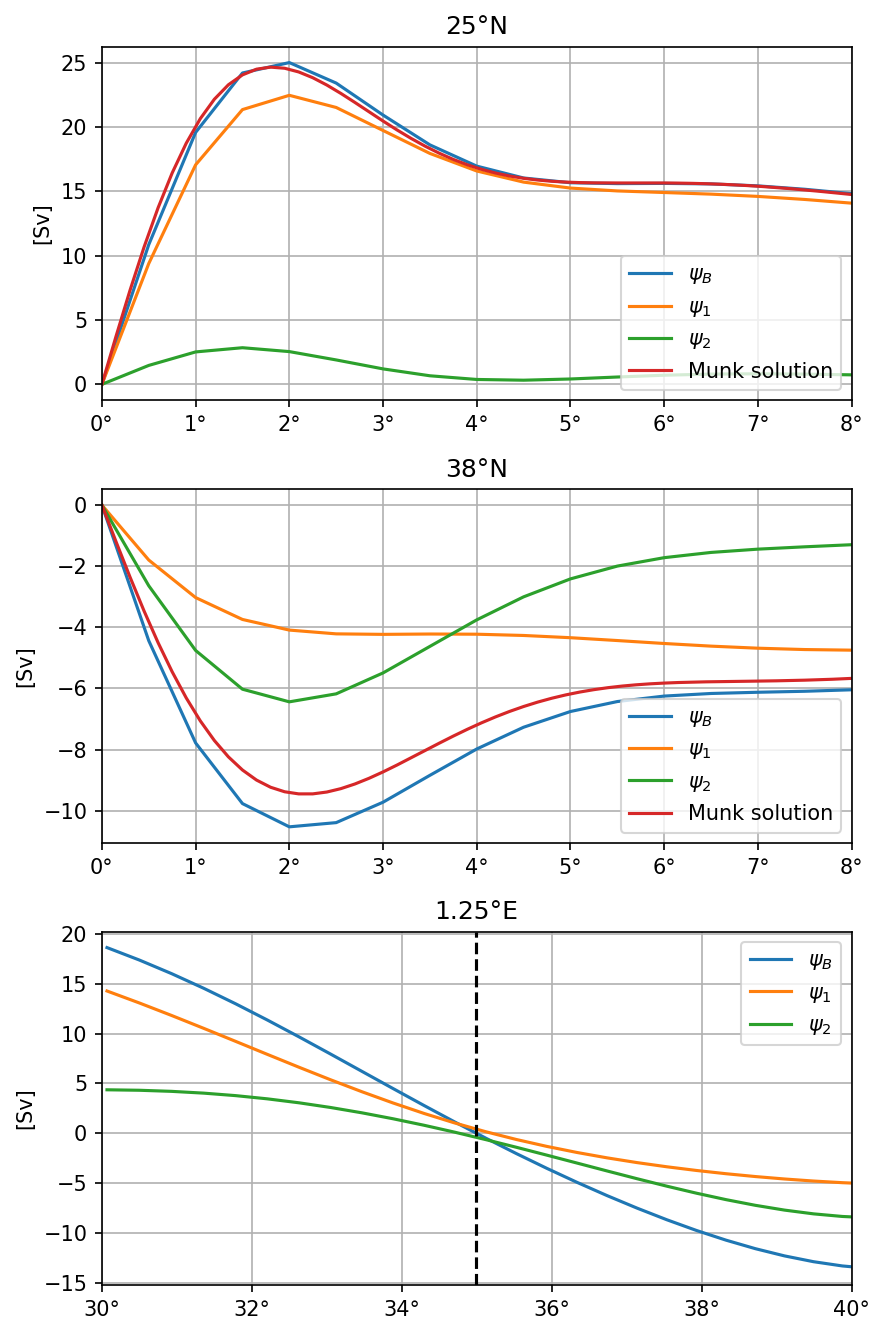

In [802]:
fig, axs = plt.subplots(nrows=3, figsize=(6,9))

psiI = -(forcing.wsc.isel(xq=-1)*grid.Lx_q/grid.βq)/1e6 # interior streamfunction from Sverdrup theory
xx = np.linspace(0, 1, 201)

for n, lat in enumerate([25, 38]):
    ax = axs[n]

    # Munk width
    δm = (Ah/grid.βq.sel(yq=lat, method='nearest').values)**(1/3)/(a*np.deg2rad(30)*cosd(lat))

    fld = psiB.sel(yq=lat, method='nearest').sel(xq=slice(0, 9))
    ax.plot(fld.xq, fld, label='$\psi_B$')
    fld = psi.sel(yq=lat, method='nearest').sel(xq=slice(0, 9))
    ax.plot(fld.xq, fld.isel(zl=0), label='$\psi_1$')
    ax.plot(fld.xq, fld.isel(zl=1), label='$\psi_2$')
    ax.plot(30*xx, float(psiI.sel(yq=lat, method='nearest')) 
            * (1 - xx - np.exp(-xx/(2*δm))*(np.cos(np.sqrt(3)*xx/(2*δm)) - 1/np.sqrt(3)*np.sin(np.sqrt(3)*xx/(2*δm)))),
           label='Munk solution')
    ax.grid()
    ax.set_xlim([0, 8])
    ax.legend()
    ax.set_title(str(lat) + '\N{DEGREE SIGN}N')

for ax in axs[:-1]:
    xticks = np.arange(0, 9, 1)
    lonFormatter = pw.plt.LongitudeFormatter(direction_labels=False)
    ax.set_xticks(xticks)
    ax.set_xticklabels(lonFormatter.format(xticks))

ax = axs[2]
lon = recirc_lon0
fld = psiB.sel(xq=lon, method='nearest').sel(yq=slice(30, 41))
ax.plot(fld.yq, fld, label='$\psi_B$')
fld = psi.sel(xq=lon, method='nearest').sel(yq=slice(30, 41))
ax.plot(fld.yq, fld.isel(zl=0), label='$\psi_1$')
ax.plot(fld.yq, fld.isel(zl=1), label='$\psi_2$')
ax.grid()
ax.set_xlim([30, 40])
ax.legend()
ax.set_title(str(lon) + '\N{DEGREE SIGN}E')
xticks = np.arange(30, 41, 2)
latFormatter = pw.plt.LatitudeFormatter(direction_labels=False)
ax.set_xticks(xticks, labels=latFormatter.format(xticks))


# find the latitude of the zero-crossing of psiB
fld = psiB.sel(xq=lon, method='nearest').sel(yq=slice(30, 41))
idx = int(np.nonzero(fld[:-1].values*fld[1:].values <= 0)[0])
recirc_lat0 = float((fld.isel(yq=idx+1)*fld.yq.isel(yq=idx) - fld.isel(yq=idx)*fld.yq.isel(yq=idx+1))
                    / (fld.isel(yq=idx+1) - fld.isel(yq=idx)))
ax.axvline(recirc_lat0, color='k', ls='--')

for ax in axs:
    ax.set_ylabel('[Sv]')

fig.subplots_adjust(hspace=.3)

fig.tight_layout()
savefig(fig, 'wbc_streamfunctions')

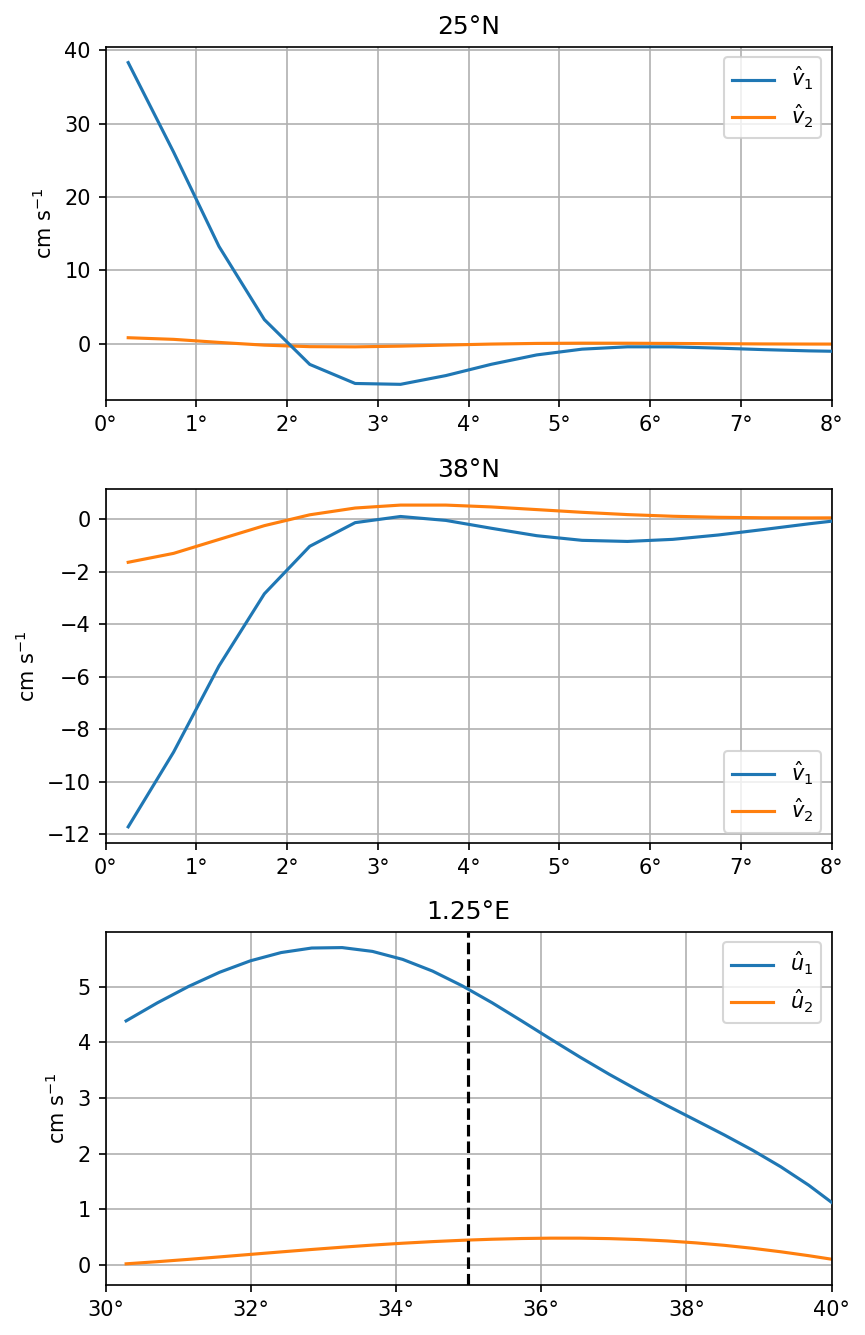

In [803]:
fig, axs = plt.subplots(nrows=3, figsize=(6,9))

for n, lat in enumerate([25, 38]):
    ax = axs[n]
    fld = 100*twa.vhat.sel(yq=lat, method='nearest').sel(xh=slice(0, 9))
    ax.plot(fld.xh, fld.isel(zl=0), label='$\hat{v}_1$', zorder=3)
    ax.plot(fld.xh, fld.isel(zl=1), label='$\hat{v}_2$')
    ax.grid()
    ax.legend()
    ax.set_xlim([0, 8])
    ax.set_title(str(lat) + '\N{DEGREE SIGN}N')
    xticks = np.arange(0, 9, 1)
    lonFormatter = pw.plt.LongitudeFormatter(direction_labels=False)
    ax.set_xticks(xticks, labels=lonFormatter.format(xticks))

ax = axs[2]
lon = recirc_lon0
fld = 100*twa.uhat.sel(xq=lon, method='nearest').sel(yh=slice(30, 41))
ax.plot(fld.yh, fld.isel(zl=0), label='$\hat{u}_1$', zorder=3)
ax.plot(fld.yh, fld.isel(zl=1), label='$\hat{u}_2$')
ax.axvline(recirc_lat0, color='k', ls='--')
ax.grid()
ax.legend()
ax.set_title(str(lon) + '\N{DEGREE SIGN}E')
ax.set_xlim([30, 40])
xticks = np.arange(30, 41, 2)
latFormatter = pw.plt.LatitudeFormatter(direction_labels=False)
ax.set_xticks(xticks, labels=latFormatter.format(xticks))

for ax in axs:
    ax.set_ylabel('cm s$^{-1}$')

fig.subplots_adjust(hspace=.3)

fig.tight_layout()
savefig(fig, 'wbc_velocities')

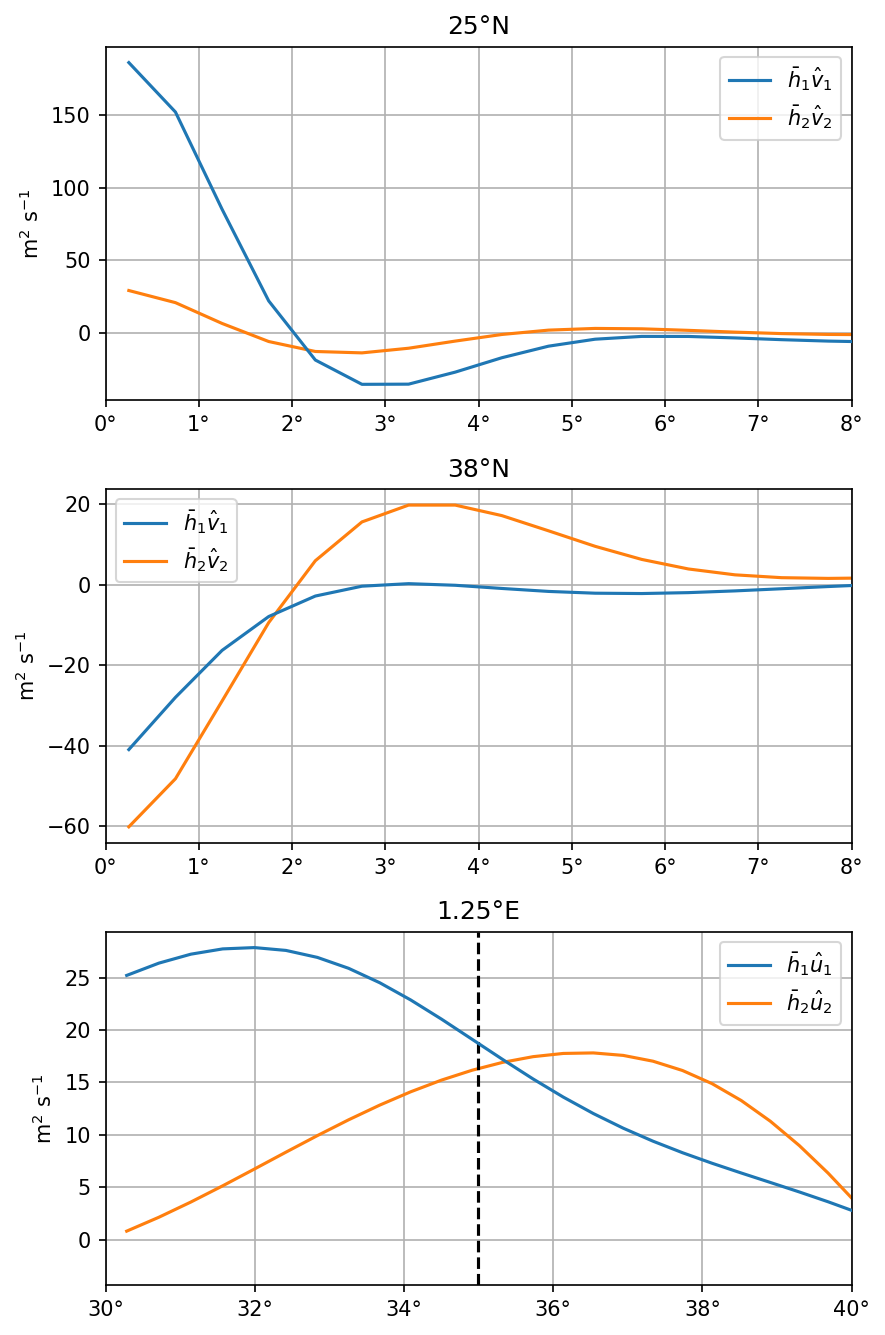

In [804]:
fig, axs = plt.subplots(nrows=3, figsize=(6,9))

for n, lat in enumerate([25, 38]):
    ax = axs[n]
    fld = (twa.h_at_v*twa.vhat).sel(yq=lat, method='nearest').sel(xh=slice(0, 9))
    ax.plot(fld.xh, fld.isel(zl=0), label=r'$\bar{h}_1 \hat{v}_1$', zorder=3)
    ax.plot(fld.xh, fld.isel(zl=1), label=r'$\bar{h}_2 \hat{v}_2$')
    ax.grid()
    ax.legend()
    ax.set_xlim([0, 8])
    ax.set_title(str(lat) + '\N{DEGREE SIGN}N')
    xticks = np.arange(0, 9, 1)
    lonFormatter = pw.plt.LongitudeFormatter(direction_labels=False)
    ax.set_xticks(xticks, labels=lonFormatter.format(xticks))

ax = axs[2]
lon = recirc_lon0
fld = (twa.h_at_u*twa.uhat).sel(xq=lon, method='nearest').sel(yh=slice(30, 41))
ax.plot(fld.yh, fld.isel(zl=0), label=r'$\bar{h}_1\hat{u}_1$', zorder=3)
ax.plot(fld.yh, fld.isel(zl=1), label=r'$\bar{h}_2\hat{u}_2$')
ax.axvline(recirc_lat0, color='k', ls='--')
ax.grid()
ax.legend()
ax.set_title(str(lon) + '\N{DEGREE SIGN}E')
ax.set_xlim([30, 40])
xticks = np.arange(30, 41, 2)
latFormatter = pw.plt.LatitudeFormatter(direction_labels=False)
ax.set_xticks(xticks, labels=latFormatter.format(xticks))


for ax in axs:
    ax.set_ylabel('m$^2$ s$^{-1}$')

fig.subplots_adjust(hspace=.3)
fig.tight_layout()

savefig(fig, 'wbc_transports')

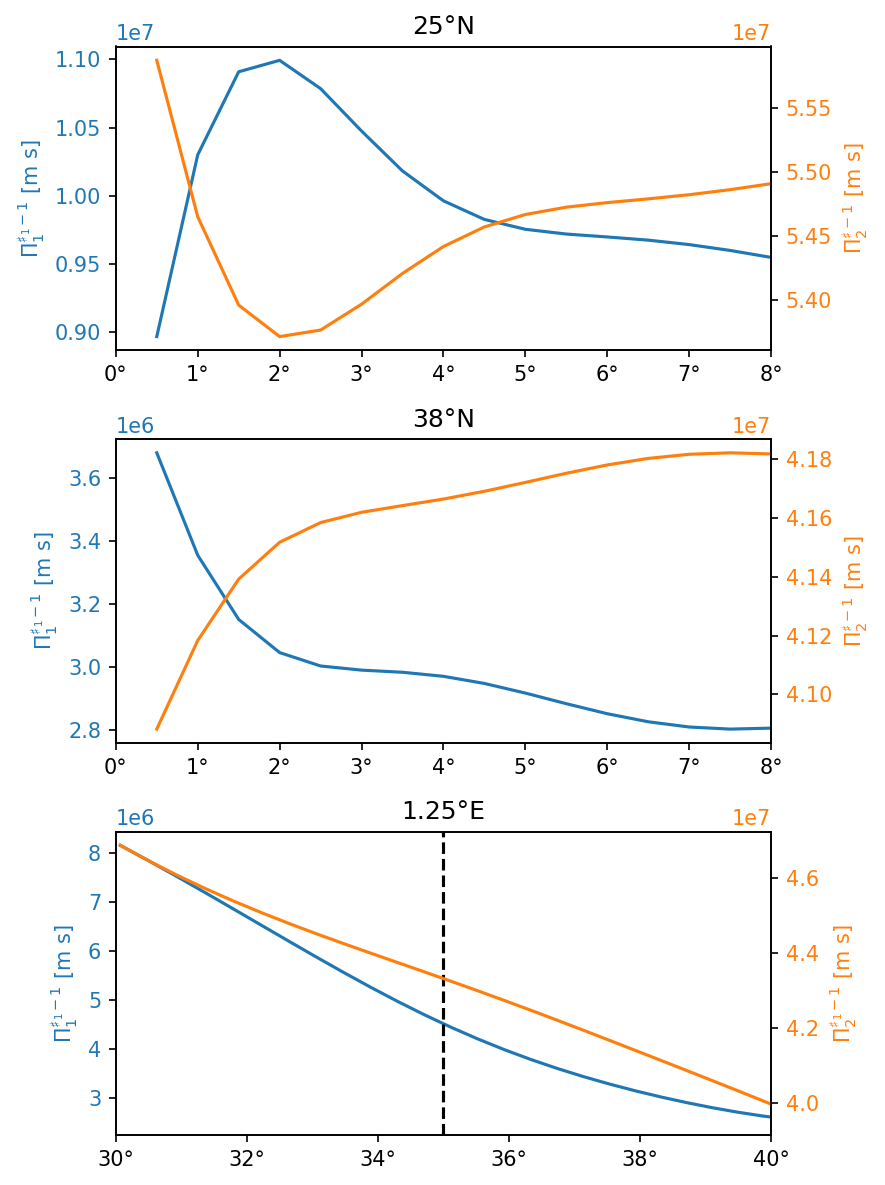

In [805]:
fig, axs = plt.subplots(nrows=3, figsize=(6,8))

for n, lat in enumerate([25, 38]):
    ax = axs[n]
    fld = 1/twa.Pi.sel(yq=lat, method='nearest').sel(xq=slice(0, 9))
    ax.plot(fld.xq, fld.isel(zl=0), color=colors[0])
    ax.tick_params(axis='y', labelcolor=colors[0])
    ax.set_ylabel(r'$\Pi^{\sharp_1-1}_1$ [m s]', color=colors[0])
    ax2 = ax.twinx()
    ax2.plot(fld.xq, fld.isel(zl=1), color=colors[1])
    ax2.tick_params(axis='y', labelcolor=colors[1])
    ax2.set_ylabel(r'$\Pi^{\sharp-1}_2$ [m s]', color=colors[1])
    ax.set_xlim([0, 8])
    ax.set_title(str(lat) + '\N{DEGREE SIGN}N')
    xticks = np.arange(0, 9, 1)
    lonFormatter = pw.plt.LongitudeFormatter(direction_labels=False)
    ax.set_xticks(xticks, labels=lonFormatter.format(xticks))
    

ax = axs[2]
lon = recirc_lon0
fld = 1/twa.Pi.sel(xq=lon, method='nearest').sel(yq=slice(30, 41))
ax.plot(fld.yq, fld.isel(zl=0), color=colors[0])
ax.tick_params(axis='y', labelcolor=colors[0])
ax.set_ylabel(r'$\Pi^{\sharp_1-1}_1$ [m s]', color=colors[0])
# ax.set_ylim(0, 1.5e-6)
ax.axvline(recirc_lat0, color='k', ls='--')
ax2 = ax.twinx()
ax2.plot(fld.yq, fld.isel(zl=1), color=colors[1])
ax2.tick_params(axis='y', labelcolor=colors[1])
ax2.set_ylabel(r'$\Pi^{\sharp_1-1}_2$ [m s]', color=colors[1])
ax.set_xlim([30, 40])
ax.set_title(str(lon) + '\N{DEGREE SIGN}E')

xticks = np.arange(30, 41, 2)
latFormatter = pw.plt.LatitudeFormatter(direction_labels=False)
ax.set_xticks(xticks, labels=latFormatter.format(xticks))

fig.subplots_adjust(hspace=.3)

# I don't know why, but the figure color gets set to none at some point. This sets it back.
fig.set_facecolor('w')

fig.tight_layout()
# savefig(fig, 'wbc_PV')

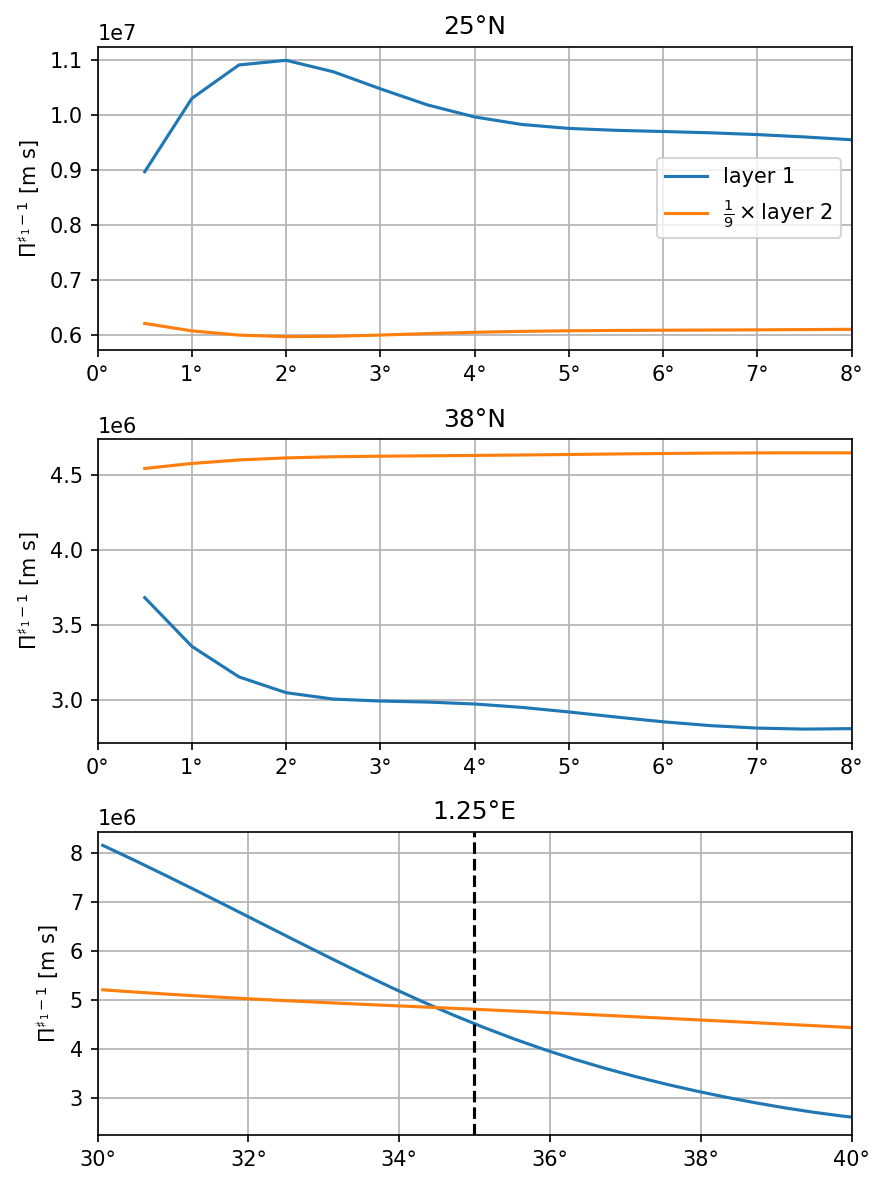

In [806]:
fig, axs = plt.subplots(nrows=3, figsize=(6,8))

for n, lat in enumerate([25, 38]):
    ax = axs[n]
    fld = 1/twa.Pi.sel(yq=lat, method='nearest').sel(xq=slice(0, 9))
    ax.plot(fld.xq, fld.isel(zl=0), color=colors[0], label='layer 1')
    ax.plot(fld.xq, fld.isel(zl=1)/9, color=colors[1], label=r'$\frac{1}{9}\times$layer 2')
    ax.set_ylabel(r'$\Pi^{\sharp_1-1}$ [m s]')
    ax.grid()
    ax.set_xlim([0, 8])
    ax.set_title(str(lat) + '\N{DEGREE SIGN}N')
    xticks = np.arange(0, 9, 1)
    lonFormatter = pw.plt.LongitudeFormatter(direction_labels=False)
    ax.set_xticks(xticks, labels=lonFormatter.format(xticks))
    
axs[0].legend()

ax = axs[2]
lon = recirc_lon0
fld = 1/twa.Pi.sel(xq=lon, method='nearest').sel(yq=slice(30, 41))
ax.plot(fld.yq, fld.isel(zl=0), color=colors[0])
ax.axvline(recirc_lat0, color='k', ls='--')
ax.plot(fld.yq, fld.isel(zl=1)/9, color=colors[1])
ax.set_ylabel(r'$\Pi^{\sharp_1-1}$ [m s]')
ax.grid()
ax.set_xlim([30, 40])
ax.set_title(str(lon) + '\N{DEGREE SIGN}E')

xticks = np.arange(30, 41, 2)
latFormatter = pw.plt.LatitudeFormatter(direction_labels=False)
ax.set_xticks(xticks, labels=latFormatter.format(xticks))

fig.subplots_adjust(hspace=.3)

# I don't know why, but the figure color gets set to none at some point. This sets it back.
fig.set_facecolor('w')

fig.tight_layout()
savefig(fig, 'wbc_PV')

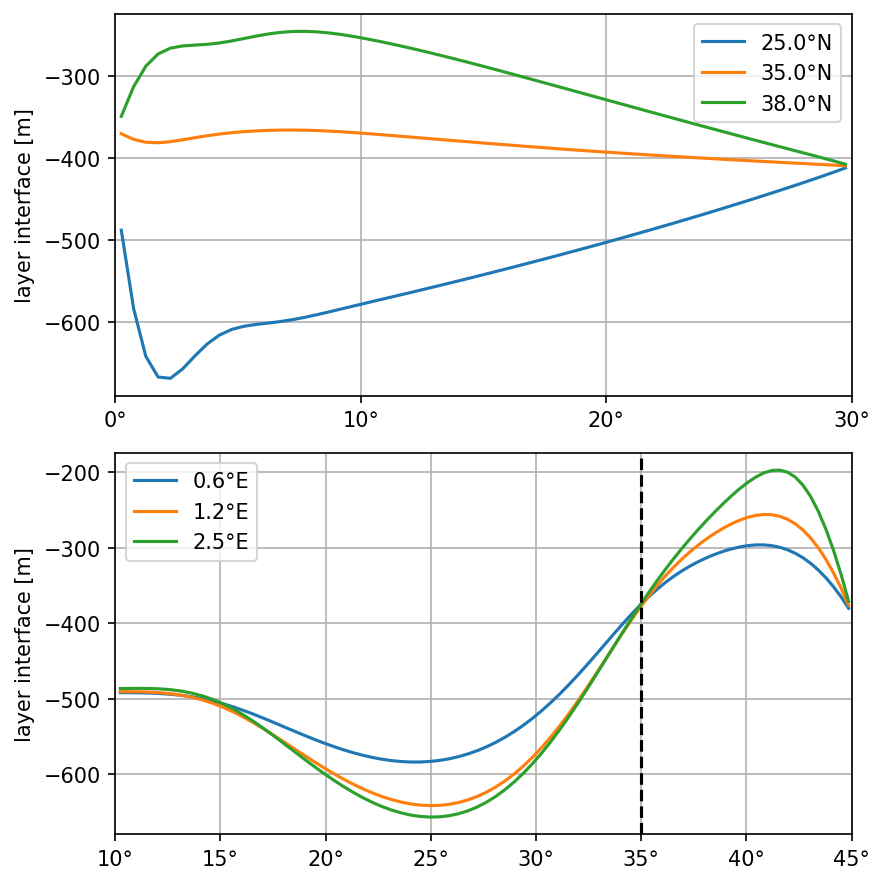

In [807]:
fig, axs = plt.subplots(nrows=2, figsize=(6,6))



ax = axs[0]
for lat in (25, recirc_lat0, 38):
    fld = prog.e.isel(time=tavg).mean(dim='time').sel(yh=lat, method='nearest')
    ax.plot(fld.xh, fld.isel(zi=1), label='{:.1f}\N{DEGREE SIGN}N'.format(lat))
    # ax.fill_between(fld.xh, -max_depth, fld.isel(zi=-1), color='.7')
    
ax.legend()
ax.set_xlim(0, 30)
ax.grid()

xticks = np.arange(0, 31, 10)
lonFormatter = pw.plt.LongitudeFormatter(direction_labels=False)
ax.set_xticks(xticks, labels=lonFormatter.format(xticks))    

ax = axs[1]
for lon in (recirc_lon0/2, recirc_lon0, 2*recirc_lon0):
    fld = prog.e.isel(zi=1).isel(time=tavg).mean(dim='time').sel(xh=lon, method='nearest')
    ax.plot(fld.yh, fld, label='{:.1f}\N{DEGREE SIGN}E'.format(lon))
ax.legend()
ax.set_xlim(10, 45)
ax.grid()
ax.axvline(recirc_lat0, color='k', ls='--')

xticks = np.arange(10, 46, 5)
latFormatter = pw.plt.LatitudeFormatter(direction_labels=False)
ax.set_xticks(xticks, labels=latFormatter.format(xticks))


for ax in axs:
    ax.set_ylabel('layer interface [m]')

fig.tight_layout()
savefig(fig, 'layer_interface')

## Meridional Sections

1.25 6.470941749000637
5 9.64880468890343
15 6.699936830084593
25 3.027635814178572
28.75 1.0487276978672484


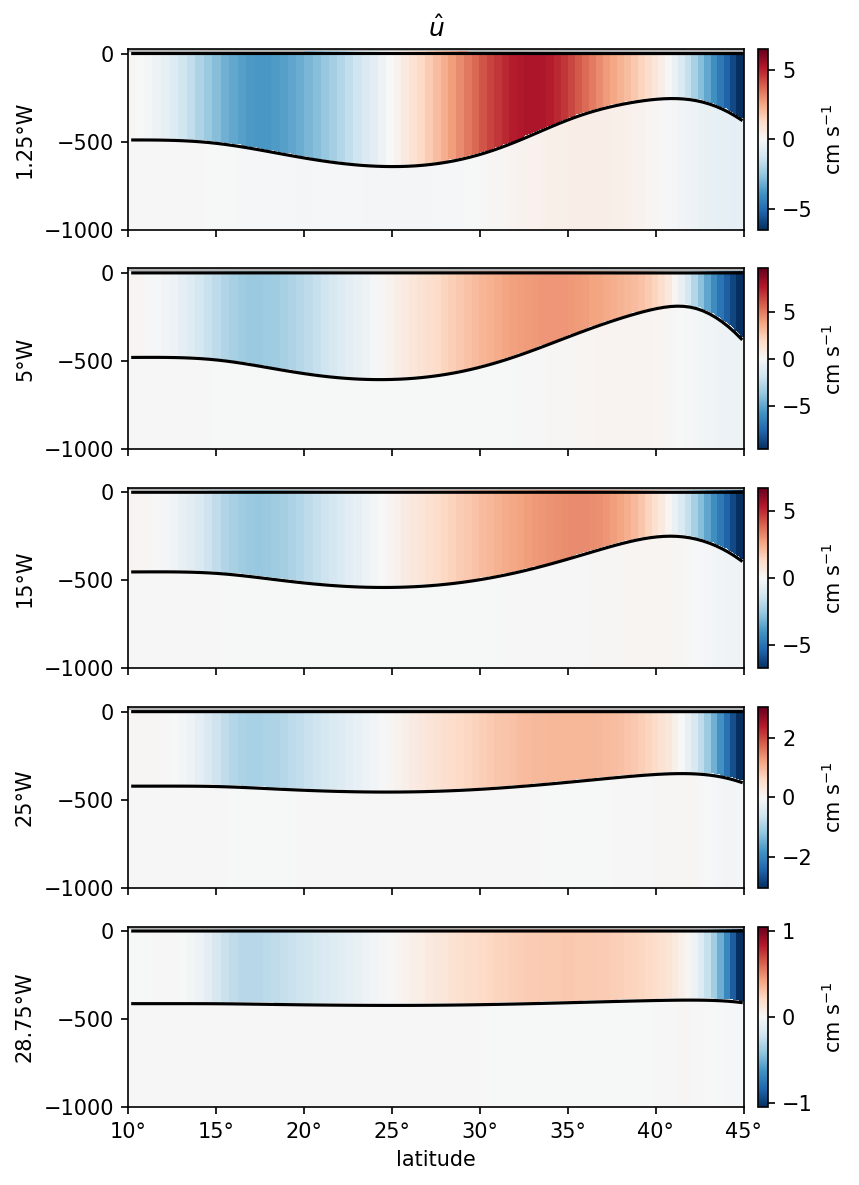

In [808]:
xlocs = [1.25, 5, 15, 25, 28.75]

fig, axs = plt.subplots(nrows=5, sharex=True, sharey=True, figsize=(6,8))

e = prog.e.isel(time=tavg).mean(dim='time')
u = 100*grid_op.interp(twa.uhat, 'X')
vms = [50, 30, 20, 10, 2]
for xloc, ax in zip(xlocs, axs):
    ax.set_facecolor('.7')
    for zi in range(3):
        ax.plot(grid.yh, e.isel(zi=zi).sel(xh=xloc, method='nearest'), color='k')
        
    y, z, q = m6toolbox.section2quadmesh(
        grid.yq.values, 
        e.sel(xh=xloc, method='nearest').values, 
        u.sel(xh=xloc, method='nearest').values, representation='plm')
    print(xloc, float(np.abs(u.sel(xh=xloc, method='nearest')).max()))
    vmax = np.abs(q).max()
    pc = ax.pcolormesh(y, z, q, vmin=-vmax, vmax=vmax, cmap='RdBu_r')
    pc.set_edgecolor('face')
    fig.colorbar(pc, ax=ax, label=r'cm s$^{-1}$', pad=.02)
    ax.set_ylabel('{:g}\N{DEGREE SIGN}W'.format(xloc))
        
ax.set_ylim([-1000, 25])
ax.set_xlim([10, 45])
axs[-1].set_xlabel('latitude')
axs[0].set_title('$\hat{u}$')
xticks = np.arange(10, 46, 5)
latFormatter = pw.plt.LatitudeFormatter(direction_labels=False)
ax.set_xticks(xticks)
ax.set_xticklabels(latFormatter.format(xticks))

fig.tight_layout()
savefig(fig, 'meridional_u')

/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/dask/utils.py:35: RuntimeWarning: All-NaN slice encountered
  return func(*args, **kwargs)
/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/dask/core.py:119: RuntimeWarning: All-NaN slice encountered
  return func(*(_execute_task(a, cache) for a in args))
/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/dask/utils.py:35: RuntimeWarning: All-NaN slice encountered
  return func(*args, **kwargs)
/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/dask/core.py:119: RuntimeWarning: All-NaN slice encountered
  return func(*(_execute_task(a, cache) for a in args))
/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/dask/utils.py:35: RuntimeWarning: All-NaN slice encountered
  return func(*args, **kwargs)
/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/dask/core.py:119: RuntimeWarning: All-NaN slice encountered
  return func(*(_execute_task(a, cache) for a in args))


0.25 38.575612687822684
5 1.042403763128306
15 1.1557737656114093


/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/dask/utils.py:35: RuntimeWarning: All-NaN slice encountered
  return func(*args, **kwargs)
/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/dask/core.py:119: RuntimeWarning: All-NaN slice encountered
  return func(*(_execute_task(a, cache) for a in args))
/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/dask/utils.py:35: RuntimeWarning: All-NaN slice encountered
  return func(*args, **kwargs)
/Users/cwolfe/miniconda3/envs/py39/lib/python3.9/site-packages/dask/core.py:119: RuntimeWarning: All-NaN slice encountered
  return func(*(_execute_task(a, cache) for a in args))


25 1.413540670738995
29.75 1.6736549296162881


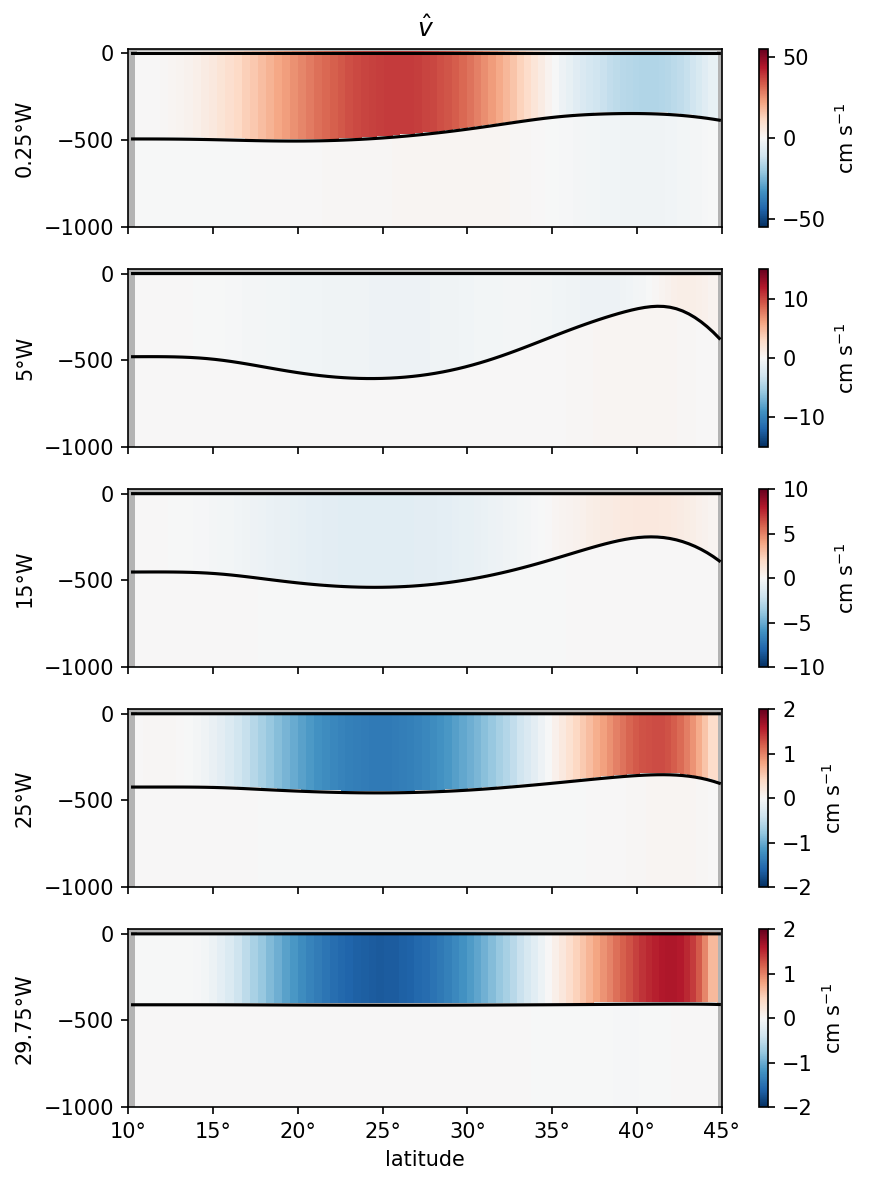

In [809]:
xlocs = [0.25, 5, 15, 25, 29.75]

fig, axs = plt.subplots(nrows=5, sharex=True, sharey=True, figsize=(6,8))

e = prog.e.isel(time=tavg).mean(dim='time')
v = 100*grid_op.interp(twa.vhat, 'Y')
vms = [55, 15, 10, 2, 2]
for xloc, ax, vmax in zip(xlocs, axs, vms):
    ax.set_facecolor('.7')
    for zi in range(3):
        ax.plot(grid.yh, e.isel(zi=zi).sel(xh=xloc, method='nearest'), color='k')
        
    y, z, q = m6toolbox.section2quadmesh(
        grid.yq.values, 
        e.sel(xh=xloc, method='nearest').values, 
        v.sel(xh=xloc, method='nearest').values, representation='plm')
    print(xloc, float(np.abs(v.sel(xh=xloc, method='nearest')).max()))
    pc = ax.pcolormesh(y, z, q, vmin=-vmax, vmax=vmax, cmap='RdBu_r')
    pc.set_edgecolor('face')
    fig.colorbar(pc, ax=ax, label=r'cm s$^{-1}$')
    ax.set_ylabel('{:g}\N{DEGREE SIGN}W'.format(xloc))
        
ax.set_ylim([-1000, 25])
ax.set_xlim([10, 45])
axs[-1].set_xlabel('latitude')
axs[0].set_title('$\hat{v}$')
xticks = np.arange(10, 46, 5)
latFormatter = pw.plt.LatitudeFormatter(direction_labels=False)
ax.set_xticks(xticks)
ax.set_xticklabels(latFormatter.format(xticks))

fig.tight_layout()
savefig(fig, 'meridional_v')

## Zonal Sections

38 3.423515625369411
34.5 5.368279533156851
30 4.124612311121966
25 0.35958611396271023
20 3.7077234464849327


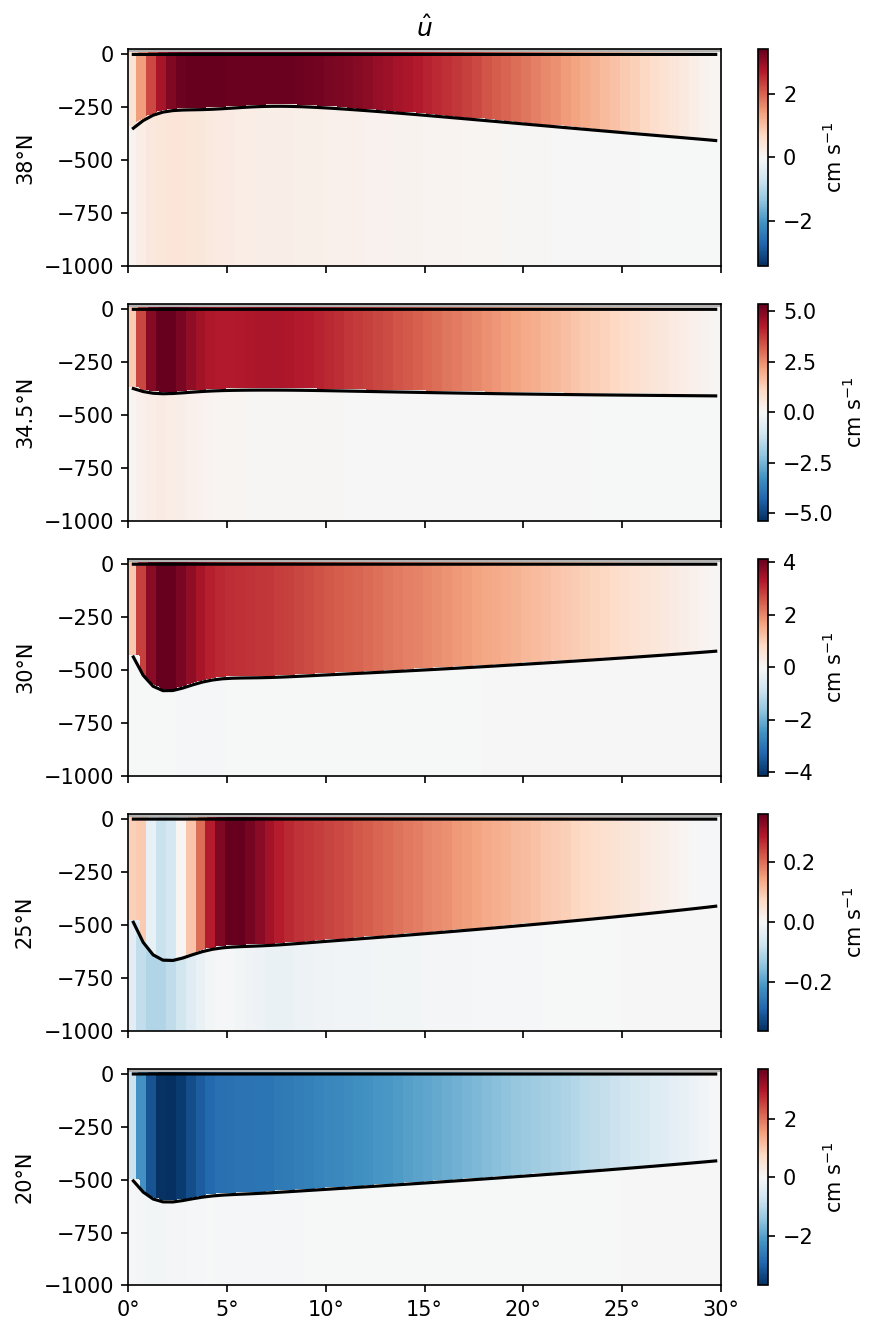

In [810]:
ylocs = [38, 34.5, 30, 25, 20]

fig, axs = plt.subplots(nrows=5, sharex=True, sharey=True, figsize=(6,9))

e = prog.e.isel(time=tavg).mean(dim='time')
u = 100*grid_op.interp(twa.uhat.fillna(0), 'X')
vms = [20, 15, 4, 2, 4]
for yloc, ax in zip(ylocs, axs):
    ax.set_facecolor('.7')
    for zi in range(2):
        ax.plot(grid.xh, e.isel(zi=zi).sel(yh=yloc, method='nearest'), color='k')
        
    x, z, q = m6toolbox.section2quadmesh(
        grid.xq.values, 
        e.sel(yh=yloc, method='nearest').values, 
        u.sel(yh=yloc, method='nearest').values, representation='plm')
    vmax = np.abs(q).max()
    pc = ax.pcolormesh(x, z, q, vmin=-vmax, vmax=vmax, cmap='RdBu_r')
    pc.set_edgecolor('face')
    print(yloc, float(np.abs(u.sel(yh=yloc, method='nearest')).max()))
    fig.colorbar(pc, ax=ax, label=r'cm s$^{-1}$')
    ax.set_ylabel('{:g}\N{DEGREE SIGN}N'.format(yloc))
        
ax.set_ylim([-1000, 25])
# ax.set_xlim([10, 45])
xticks = np.arange(0, 31, 5)
lonFormatter = pw.plt.LongitudeFormatter(direction_labels=False)
ax.set_xticks(xticks)
ax.set_xticklabels(lonFormatter.format(xticks))
axs[0].set_title('$\hat{u}$')

fig.tight_layout()
savefig(fig, 'zonal_u')

38 12.28795558411529
34.5 4.537342964218998
30 31.561587289589355
25 38.126363266101684
20 25.035659821980012


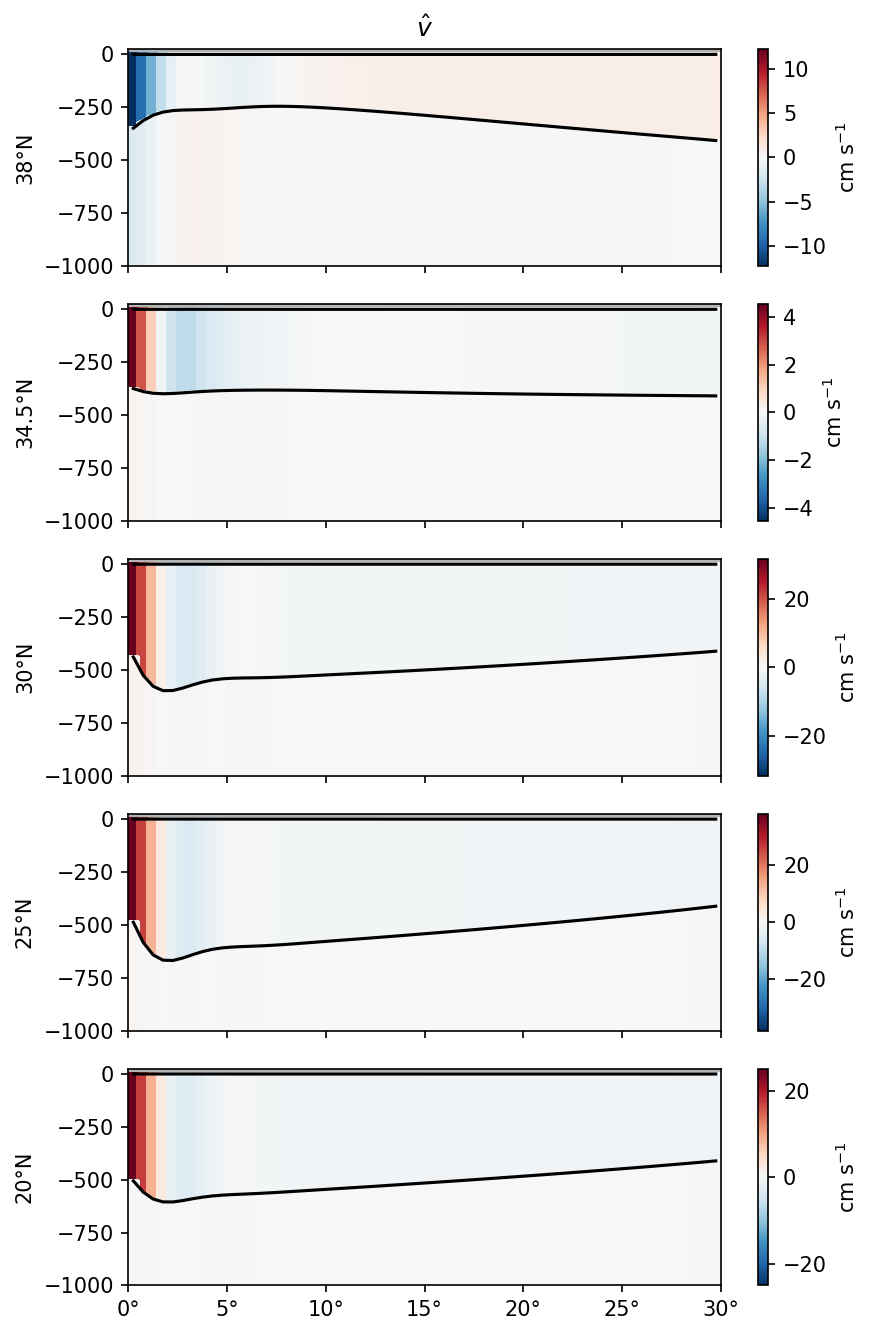

In [811]:
ylocs = [38, 34.5, 30, 25, 20]

fig, axs = plt.subplots(nrows=5, sharex=True, sharey=True, figsize=(6,9))

e = prog.e.isel(time=tavg).mean(dim='time')
v = 100*grid_op.interp(twa.vhat, 'Y')
vms = [55, 70, 85, 75, 45]
for yloc, ax, vmax in zip(ylocs, axs, vms):
    ax.set_facecolor('.7')
    for zi in range(2):
        ax.plot(grid.xh, e.isel(zi=zi).sel(yh=yloc, method='nearest'), color='k')
        
    x, z, q = m6toolbox.section2quadmesh(
        grid.xq.values, 
        e.sel(yh=yloc, method='nearest').values, 
        v.sel(yh=yloc, method='nearest').values, representation='plm')
    vmax = np.abs(q).max()
    pc = ax.pcolormesh(x, z, q, vmin=-vmax, vmax=vmax, cmap='RdBu_r')
    pc.set_edgecolor('face')
    print(yloc, float(np.abs(v.sel(yh=yloc, method='nearest')).max()))
    fig.colorbar(pc, ax=ax, label=r'cm s$^{-1}$')
    ax.set_ylabel('{:g}\N{DEGREE SIGN}N'.format(yloc))
        
ax.set_ylim([-1000, 25])
# ax.set_xlim([10, 45])
xticks = np.arange(0, 31, 5)
lonFormatter = pw.plt.LongitudeFormatter(direction_labels=False)
ax.set_xticks(xticks)
ax.set_xticklabels(lonFormatter.format(xticks))
axs[0].set_title('$\hat{v}$')

fig.tight_layout()
savefig(fig, 'zonal_v')

# Close everything

In [812]:
grid.close()
ic.close()
forcing.close()
stats.close()
prog.close()
cont.close()